# Q8 — A Hierarchical Bayesian Observer with Uncertain Prior Context

**Question (template Q8):** Simulate a Hierarchical Bayesian observer (Lee & Mumford, 2003, *JOSA A* — [pdf](https://www.cnbc.cmu.edu/~tai/papers/lee_mumford_josa.pdf)) that "believes" that in some trials the prior is uniform, and in others it is circular (Von Mises). **Can this model reproduce the observed bimodality of subject estimate distributions?**

We use the "four priors" motion-direction estimation dataset from [Laquitaine & Gardner, *Neuron* 2018](https://doi.org/10.1016/j.neuron.2017.12.011) ([source repo](https://github.com/steevelaquitaine/projInference/tree/gh-pages/notebooks)): 12 subjects estimated motion direction under 4 block-wise circular priors (std 10/40/60/80°, mean 225°) and 3 coherence levels. Laquitaine & Gardner found that despite good mean/variance fits from a standard Bayesian observer, subject estimate distributions were **bimodal**, and explained this with a **switching observer** that reports either the prior or the evidence, never a blend.

**Hypothesis:** a higher-level context node infers *which* generative model (uninformative uniform vs. informative von Mises) is in force on each trial; this categorical inference is itself uncertain, and each context's report is a pure source (never a weighted combination). Trial-to-trial switching between these pure reports produces an aggregate **mixture of two unimodal components** — i.e. bimodality — even though each single-trial report is unimodal.

This notebook: (1) quantifies real bimodality, (2) implements the standard single-prior Bayesian observer as baseline, (3) implements the hierarchical/switching observer, (4) compares simulated vs. real bimodality.

In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, spearmanr, binomtest
from scipy.special import i0e, logsumexp
from scipy.optimize import minimize_scalar

plt.rcParams["figure.figsize"] = [10, 4]
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RNG = np.random.default_rng(42)

## 1. Load the dataset

Same source used by the NMA loader notebook (`laquitaine_human_errors.ipynb`):

In [2]:
DATA_URL = "https://github.com/steevelaquitaine/projInference/raw/gh-pages/data/csv/data01_direction4priors.csv"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data01_direction4priors.csv")

if not os.path.exists(DATA_PATH):
    r = requests.get(DATA_URL, timeout=30)
    r.raise_for_status()
    with open(DATA_PATH, "wb") as f:
        f.write(r.content)

data = pd.read_csv(DATA_PATH)
data.head()

,trial_index,trial_time,response_arrow_start_angle,motion_direction,motion_coherence,estimate_x,estimate_y,reaction_time,raw_response_time,prior_std,prior_mean,subject_id,experiment_name,experiment_id,session_id,run_id
0,1,0.000000,NaN,225,0.12,-1.749685,-1.785666,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
1,2,2.730730,NaN,225,0.12,-1.819693,-1.714269,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
2,3,4.913950,NaN,235,0.06,-1.562674,-1.951422,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
3,4,6.997296,NaN,225,0.06,-1.601388,-1.919781,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
4,5,9.097130,NaN,215,0.24,-1.639461,-1.887371,NaN,NaN,10,225,1,data01_direction4priors,11,1,1


### Data dictionary (relevant columns)

- `motion_direction`: true stimulus direction (deg).
- `motion_coherence`: sensory noise proxy (higher = less noisy).
- `estimate_x`, `estimate_y`: Cartesian coordinates of the subject's estimate.
- `prior_std`, `prior_mean`: block generative-distribution std (10/40/60/80°) and mean (225°).
- `subject_id`: subject identifier (12 subjects).

We convert the estimate to an angle and compute the circular error relative to the true direction.

In [3]:
def wrap_deg(x):
    """wrap angle in degrees to [0, 360)"""
    return np.mod(x, 360)


def circ_diff_deg(a, b):
    """shortest signed circular difference a - b, in degrees, range (-180, 180]"""
    return np.mod(np.asarray(a) - np.asarray(b) + 180, 360) - 180


data["estimate_angle"] = wrap_deg(np.degrees(np.arctan2(data["estimate_y"], data["estimate_x"])))
data["error_deg"] = circ_diff_deg(data["estimate_angle"], data["motion_direction"])

# drop trials with no valid estimate (e.g. fixation-only rows in the raw file)
data = data.dropna(subset=["estimate_angle", "motion_direction", "prior_std", "prior_mean", "motion_coherence"]).reset_index(drop=True)

data[["subject_id", "motion_direction", "motion_coherence", "prior_std", "prior_mean", "estimate_angle", "error_deg"]].head()

,subject_id,motion_direction,motion_coherence,prior_std,prior_mean,estimate_angle,error_deg
0,1,225,0.12,10,225,225.583113,0.583113
1,1,225,0.12,10,225,223.291282,-1.708718
2,1,235,0.06,10,225,231.312691,-3.687309
3,1,225,0.06,10,225,230.166776,5.166776
4,1,215,0.24,10,225,229.020860,14.020860


In [4]:
print("N subjects:", data["subject_id"].nunique())
print("Prior std levels (deg):", sorted(data["prior_std"].unique()))
print("Prior mean levels (deg):", sorted(data["prior_mean"].unique()))
print("Motion coherence levels:", sorted(data["motion_coherence"].unique()))
print("N trials (with valid estimate):", len(data))

N subjects: 12
Prior std levels (deg): [np.int64(10), np.int64(20), np.int64(40), np.int64(80)]
Prior mean levels (deg): [np.int64(225)]
Motion coherence levels: [np.float64(0.06), np.float64(0.12), np.float64(0.24)]
N trials (with valid estimate): 83210


## 2. Quantify bimodality in the real data

We use **Sarle's bimodality coefficient** (BC):

$$BC = \frac{g^2 + 1}{k}$$

where $g$ is sample-bias-corrected skewness and $k$ is the sample-bias-corrected (non-excess) kurtosis (Joanes & Gill, 1998 correction, matching the original SAS/Sarle formulation). For a uniform distribution $BC = 5/9 \approx 0.555$; values **above** this threshold are conventionally taken as evidence of bimodality/multimodality, values below indicate unimodality. This is a heuristic, not a formal test, but it is convenient for comparing many conditions and models at once.

**Grouping strategy (matching Laquitaine & Gardner, 2018):** We group trials by `(prior_std, motion_coherence, motion_direction)`, fixing the true direction per group, and pool across subjects. Within each group we recenter the raw `estimate_angle` on the group's fixed `motion_direction` (a lossless rigid rotation) before computing BC. This ensures the two expected modes — at the true direction and at the fixed prior mean (225°) — sit at fixed locations within each group, rather than being smeared by pooling trials with different prior–evidence offsets.

In [5]:
BC_UNIFORM = 5 / 9
CONDITION_COLS = ["subject_id", "prior_std", "motion_coherence"]
DIRECTION_COLS = ["prior_std", "motion_coherence", "motion_direction"]
MIN_TRIALS = 15


def bimodality_coefficient(x):
    """Sarle's bimodality coefficient. BC > 5/9 conventionally suggests bimodality.
    Uses sample-bias-corrected skewness and kurtosis (Joanes & Gill, 1998), matching
    the original SAS/Sarle formulation (SAS Institute Inc, 1990, p. 561; see Pfister
    et al., 2013, Frontiers in Psychology, for the corrected/clarified formula)."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 4:
        return np.nan
    g = skew(x, bias=False)
    k = kurtosis(x, fisher=False, bias=False)  # Pearson kurtosis (normal = 3)
    if k == 0:
        return np.nan
    return (g ** 2 + 1) / k


def bc_by_condition(df, col, group_cols=CONDITION_COLS, min_n=MIN_TRIALS):
    return (
        df.groupby(group_cols)[col]
        .apply(lambda x: bimodality_coefficient(x) if len(x) >= min_n else np.nan)
        .reset_index(name=f"bc_{col}")
    )


def bc_by_direction(df, estimate_col, min_n=MIN_TRIALS):
    """Compute BC on raw estimates grouped by (prior_std, coherence, motion_direction),
    recentered on each group's fixed true direction, pooled across subjects."""
    PRIOR_MEAN = df["prior_mean"].iloc[0]
    rows = []
    for (pstd, coh, mdir), grp in df.groupby(["prior_std", "motion_coherence", "motion_direction"]):
        if len(grp) < min_n:
            continue
        centered = circ_diff_deg(grp[estimate_col], mdir)
        bc = bimodality_coefficient(centered)
        offset = circ_diff_deg(PRIOR_MEAN, mdir)
        rows.append({
            "prior_std": pstd, "motion_coherence": coh, "motion_direction": mdir,
            "offset": offset, "n_trials": len(grp), "bc": bc,
        })
    return pd.DataFrame(rows)


bc_real = bc_by_direction(data, "estimate_angle").dropna()
print(f"{len(bc_real)} (prior_std x coherence x motion_direction) groups with >= {MIN_TRIALS} trials")
print(f"Fraction classified bimodal (BC > 5/9): {(bc_real.bc > BC_UNIFORM).mean():.3f}")
print(f"Mean BC: {bc_real.bc.mean():.3f}, max BC: {bc_real.bc.max():.3f}")
bc_real.sort_values("bc", ascending=False).head(10)

202 (prior_std x coherence x motion_direction) groups with >= 15 trials
Fraction classified bimodal (BC > 5/9): 0.015
Mean BC: 0.259, max BC: 0.698


,prior_std,motion_coherence,motion_direction,offset,n_trials,bc
84,40,0.24,155,70,78,0.697733
82,40,0.12,305,-80,78,0.614136
182,80,0.24,165,60,155,0.567089
173,80,0.24,75,150,95,0.550653
196,80,0.24,305,-80,153,0.544523
88,40,0.24,195,30,156,0.537909
86,40,0.24,175,50,109,0.512448
44,20,0.24,255,-30,158,0.507992
37,20,0.24,185,40,79,0.507172
83,40,0.12,315,-90,78,0.500809


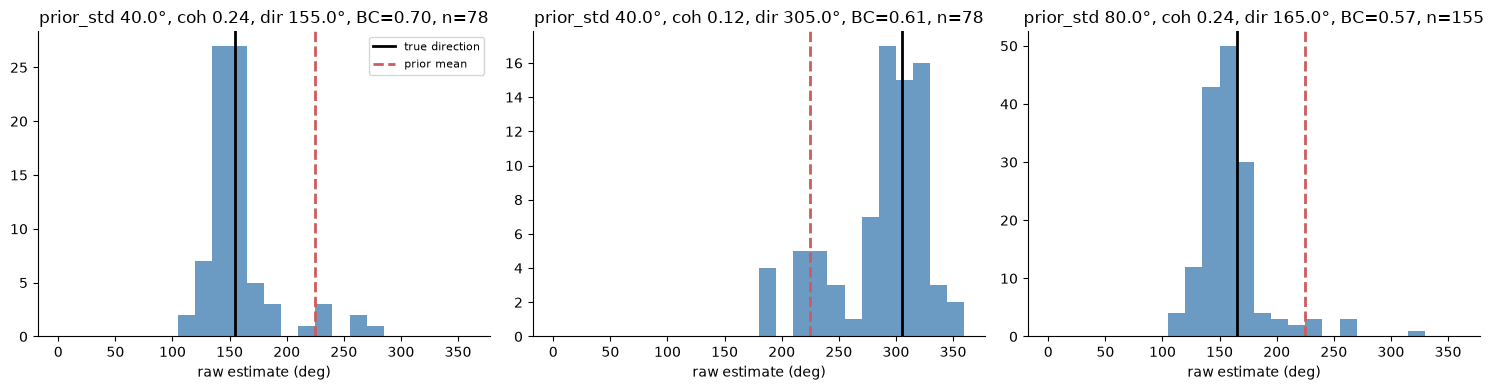

In [6]:
PRIOR_MEAN_FIXED = data["prior_mean"].iloc[0]
top_conditions = bc_real.sort_values("bc", ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top_conditions.iterrows()):
    mask = (
        (data.prior_std == row.prior_std)
        & (data.motion_coherence == row.motion_coherence)
        & (data.motion_direction == row.motion_direction)
    )
    subset = data[mask]
    ax.hist(subset["estimate_angle"], bins=24, range=(0, 360), color="steelblue", alpha=0.8)
    ax.axvline(row.motion_direction, color="black", linestyle="-", linewidth=2, label="true direction")
    ax.axvline(PRIOR_MEAN_FIXED, color="indianred", linestyle="--", linewidth=2, label="prior mean")
    ax.set_title(
        f"prior_std {row.prior_std}°, coh {row.motion_coherence}, dir {row.motion_direction}°, "
        f"BC={row.bc:.2f}, n={mask.sum()}"
    )
    ax.set_xlabel("raw estimate (deg)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Baseline: standard (single-prior) Bayesian observer

The observer combines one noisy measurement $m \sim \text{VM}(\theta_{true}, \kappa_{sens})$ with a single, always-trusted prior $\text{VM}(\mu_{prior}, \kappa_{prior})$. Since the product of two von Mises densities is itself von Mises, the posterior has closed form:

$$p(\theta \mid m) = \text{VM}(\theta;\ \mu_R,\ R), \qquad R e^{i\mu_R} = \kappa_{sens} e^{im} + \kappa_{prior} e^{i\mu_{prior}}$$

This posterior is **always unimodal**, giving our null model for bimodality. We estimate $\kappa_{sens}(\text{coherence})$ from subject-error concentration in the weakest-prior block (`prior_std`=80°) via the MLE approximation $\kappa \approx A_1^{-1}(R)$ (Fisher, 1993, *Statistical Analysis of Circular Data*, eq. p. 88; verified against [`circ_kappa.m`](https://github.com/circstat/circstat-matlab/blob/master/circ_kappa.m), Berens 2009), and $\kappa_{prior}(\text{prior\_std})$ via the small-angle approximation $\kappa \approx 1/\sigma_{rad}^2$.

In [7]:
def a1_inverse(R):
    """Approximate inverse of A1(kappa) = R (mean resultant length) for the von Mises
    MLE of concentration, from Fisher (1993), Statistical Analysis of Circular Data,
    equation p. 88. This piecewise polynomial approximation (identical coefficients)
    is implemented as `circ_kappa.m` in the CircStat toolbox (Berens, 2009, JSS 31(10)):
    https://github.com/circstat/circstat-matlab/blob/master/circ_kappa.m, whose docstring
    cites: "References: Statistical analysis of circular data, Fisher, equation p. 88"."""
    R = np.clip(np.asarray(R, dtype=float), 1e-8, 0.999999)
    return np.where(
        R < 0.53,
        2 * R + R ** 3 + 5 * R ** 5 / 6,
        np.where(
            R < 0.85,
            -0.4 + 1.39 * R + 0.43 / (1 - R),
            1 / (R ** 3 - 4 * R ** 2 + 3 * R),
        ),
    )


def kappa_from_errors(errors_deg):
    """Estimate von Mises concentration from a sample of circular errors (degrees)."""
    theta = np.radians(errors_deg)
    R = np.hypot(np.mean(np.cos(theta)), np.mean(np.sin(theta)))
    return float(a1_inverse(R))


def kappa_prior_from_std(prior_std_deg):
    """Small-angle von Mises <-> Gaussian approximation: kappa ~= 1 / std_rad^2."""
    std_rad = np.radians(prior_std_deg)
    return 1.0 / std_rad ** 2


weakest_prior_std = data["prior_std"].max()
kappa_sensory_by_coh = {
    coh: kappa_from_errors(grp["error_deg"])
    for coh, grp in data[data.prior_std == weakest_prior_std].groupby("motion_coherence")
}
print("kappa_sensory by coherence (from prior_std =", weakest_prior_std, "block):")
for coh, k in sorted(kappa_sensory_by_coh.items()):
    print(f"  coherence={coh}: kappa_sensory={k:.2f}")

print("\nkappa_prior by prior_std:")
for std in sorted(data["prior_std"].unique()):
    print(f"  prior_std={std}deg: kappa_prior={kappa_prior_from_std(std):.2f}")

kappa_sensory by coherence (from prior_std = 80 block):
  coherence=0.06: kappa_sensory=1.10
  coherence=0.12: kappa_sensory=2.24
  coherence=0.24: kappa_sensory=6.01

kappa_prior by prior_std:
  prior_std=10deg: kappa_prior=32.83
  prior_std=20deg: kappa_prior=8.21
  prior_std=40deg: kappa_prior=2.05
  prior_std=80deg: kappa_prior=0.51


In [8]:
data["kappa_sensory"] = data["motion_coherence"].map(kappa_sensory_by_coh)
data["kappa_prior"] = kappa_prior_from_std(data["prior_std"])


def von_mises_combination(mu1, kappa1, mu2, kappa2):
    """Resultant (mu, kappa) of the von Mises 'posterior' proportional to VM(mu1,kappa1)*VM(mu2,kappa2)."""
    vx = kappa1 * np.cos(mu1) + kappa2 * np.cos(mu2)
    vy = kappa1 * np.sin(mu1) + kappa2 * np.sin(mu2)
    R = np.hypot(vx, vy)
    mu_R = np.arctan2(vy, vx)
    return mu_R, R


def simulate_baseline_trial(true_dir_deg, prior_mean_deg, kappa_sensory, kappa_prior, rng):
    true_dir = np.radians(true_dir_deg)
    prior_mean = np.radians(prior_mean_deg)
    m = rng.vonmises(true_dir, max(kappa_sensory, 1e-6))
    mu_R, R = von_mises_combination(m, kappa_sensory, prior_mean, kappa_prior)
    resp = rng.vonmises(mu_R, max(R, 1e-6))
    return np.degrees(resp) % 360


data["baseline_estimate"] = [
    simulate_baseline_trial(row.motion_direction, row.prior_mean, row.kappa_sensory, row.kappa_prior, RNG)
    for row in data.itertuples()
]
data["baseline_error_deg"] = circ_diff_deg(data["baseline_estimate"], data["motion_direction"])
data[["motion_direction", "prior_mean", "kappa_sensory", "kappa_prior", "baseline_estimate", "baseline_error_deg"]].head()

,motion_direction,prior_mean,kappa_sensory,kappa_prior,baseline_estimate,baseline_error_deg
0,225,225,2.239938,32.828064,248.002956,23.002956
1,225,225,2.239938,32.828064,220.898352,-4.101648
2,235,225,1.095569,32.828064,223.340333,-11.659667
3,225,225,1.095569,32.828064,218.953731,-6.046269
4,215,225,6.007733,32.828064,238.758057,23.758057


## 4. Hierarchical Bayesian observer (Q8)

Per Lee & Mumford (2003), a higher level infers *which* generative model is in force: $H_{unif}$ (prior $=\text{Uniform}(0,2\pi)$) or $H_{vm}$ (prior $=\text{VM}(\mu_{prior},\kappa_{prior})$), with hyperprior $p(H_{vm})=1-p(\text{p\_uniform})$. Following Laquitaine & Gardner's (2018) **switching observer** — *"a model that switched between prior and sensory evidence rather than integrating the two... better explained the data"* — each context reports a pure source, never a blend: $H_{unif}\to\text{VM}(m,\kappa_{sens})$, $H_{vm}\to\text{VM}(\mu_{prior},\kappa_{prior})$.

Context inference still uses the combined-posterior concentration $R$ (evidence/prior agreement) to score each context's marginal likelihood via the von Mises Bessel-function identity:

$$p(m \mid H_{unif}) = \frac{1}{2\pi}, \qquad p(m \mid H_{vm}) = \frac{I_0(R)}{2\pi\, I_0(\kappa_{sens})\, I_0(\kappa_{prior})}$$

$$P(H_{vm}\mid m) = \sigma\!\left(\log\frac{p(H_{vm})}{p(H_{unif})} + \log \frac{I_0(R)}{I_0(\kappa_{sens})\,I_0(\kappa_{prior})}\right)$$

On each trial the observer commits to one context per $P(H\mid m)$ and reports either the raw measurement or the bare prior — never a compromise — so the aggregate distribution across trials can become bimodal.

In [9]:
def context_posterior_and_components(m, prior_mean, kappa_sensory, kappa_prior, p_uniform):
    """Exact hierarchical inference over {H_uniform, H_vm} given one measurement m (radians).

    Returns:
        p_vm_given_m: posterior probability of the von-Mises-prior context
        (mu_u, kappa_u): parameters of the H_uniform *report* distribution (= likelihood)
        (mu_vm, kappa_vm): parameters of the H_vm *report* distribution (= bare prior,
            per the switching-observer account of Laquitaine & Gardner 2018)
    """
    mu_u, kappa_u = m, kappa_sensory
    mu_vm, kappa_vm = prior_mean, kappa_prior

    # Context inference still uses the *combined* posterior concentration R (evidence/prior
    # agreement), even though the H_vm report itself discards the combination and uses the
    # bare prior above. R is only used here to compute how likely m is under each context.
    _, R = von_mises_combination(m, kappa_sensory, prior_mean, kappa_prior)

    # log[ I0(R) / (I0(kappa_sensory) * I0(kappa_prior)) ], computed via the exponentially
    # scaled Bessel function i0e(x) = I0(x) * exp(-x) to avoid overflow at large kappa.
    log_bessel_ratio = (
        (R - kappa_sensory - kappa_prior)
        + np.log(i0e(R))
        - np.log(i0e(kappa_sensory))
        - np.log(i0e(kappa_prior))
    )

    prior_odds = (1 - p_uniform) / p_uniform
    log_posterior_odds = np.log(prior_odds) + log_bessel_ratio
    p_vm_given_m = 1.0 / (1.0 + np.exp(-log_posterior_odds))

    return p_vm_given_m, (mu_u, kappa_u), (mu_vm, kappa_vm)


def simulate_hierarchical_trial(true_dir_deg, prior_mean_deg, kappa_sensory, kappa_prior, p_uniform, rng):
    true_dir = np.radians(true_dir_deg)
    prior_mean = np.radians(prior_mean_deg)

    m = rng.vonmises(true_dir, max(kappa_sensory, 1e-6))
    p_vm, (mu_u, k_u), (mu_vm, k_vm) = context_posterior_and_components(
        m, prior_mean, kappa_sensory, kappa_prior, p_uniform
    )

    if rng.random() < p_vm:
        resp = rng.vonmises(mu_vm, max(k_vm, 1e-6))
    else:
        resp = rng.vonmises(mu_u, max(k_u, 1e-6))

    return np.degrees(resp) % 360, p_vm

In [10]:
P_UNIFORM = 0.5  # hyperprior: equal belief that context is uninformative vs. informative

hier_estimate, hier_p_vm = [], []
for row in data.itertuples():
    resp, p_vm = simulate_hierarchical_trial(
        row.motion_direction, row.prior_mean, row.kappa_sensory, row.kappa_prior, P_UNIFORM, RNG
    )
    hier_estimate.append(resp)
    hier_p_vm.append(p_vm)

data["hier_estimate"] = hier_estimate
data["hier_error_deg"] = circ_diff_deg(data["hier_estimate"], data["motion_direction"])
data["hier_p_vm"] = hier_p_vm

data[["prior_std", "motion_coherence", "hier_p_vm", "hier_estimate", "hier_error_deg"]].head()

,prior_std,motion_coherence,hier_p_vm,hier_estimate,hier_error_deg
0,10,0.12,0.769290,192.168600,-32.831400
1,10,0.12,0.684351,225.812803,0.812803
2,10,0.06,0.206645,32.798971,157.798971
3,10,0.06,0.559261,109.996725,-115.003275
4,10,0.24,0.844058,231.643362,16.643362


## 5. Compare: subject data vs. baseline vs. hierarchical model

First, a direct visual comparison on the same `(prior_std, motion_coherence, motion_direction)` conditions that showed the strongest bimodality in the real data. We plot raw estimate distributions (not errors), with vertical lines marking the true direction and the fixed prior mean (225°).

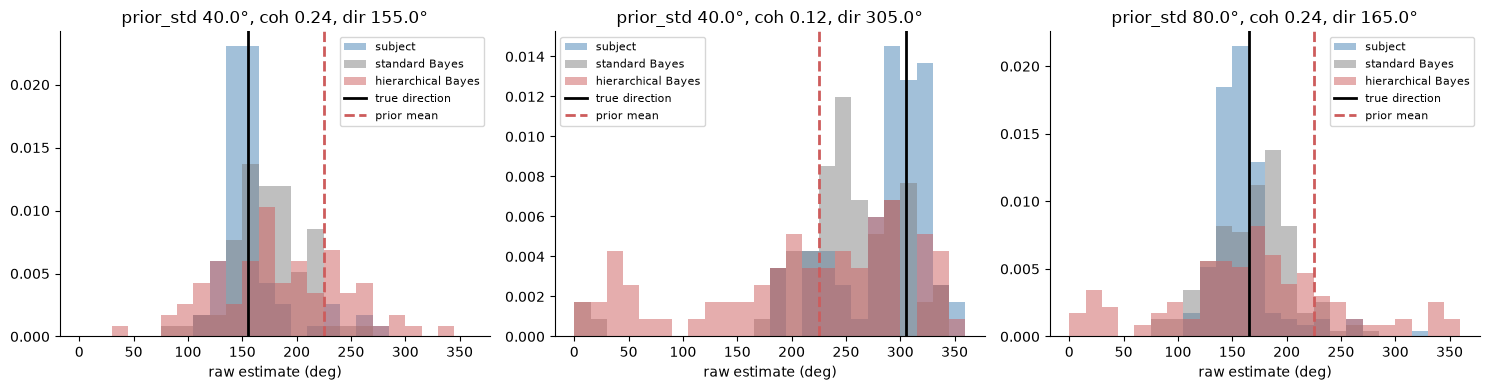

In [11]:
PRIOR_MEAN_FIXED = data["prior_mean"].iloc[0]
top_conditions = bc_real.sort_values("bc", ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top_conditions.iterrows()):
    mask = (
        (data.prior_std == row.prior_std)
        & (data.motion_coherence == row.motion_coherence)
        & (data.motion_direction == row.motion_direction)
    )
    subset = data[mask]
    bins = np.linspace(0, 360, 25)
    ax.hist(subset["estimate_angle"], bins=bins, alpha=0.5, density=True, label="subject", color="steelblue")
    ax.hist(subset["baseline_estimate"], bins=bins, alpha=0.5, density=True, label="standard Bayes", color="gray")
    ax.hist(subset["hier_estimate"], bins=bins, alpha=0.5, density=True, label="hierarchical Bayes", color="indianred")
    ax.axvline(row.motion_direction, color="black", linestyle="-", linewidth=2, label="true direction")
    ax.axvline(PRIOR_MEAN_FIXED, color="indianred", linestyle="--", linewidth=2, label="prior mean")
    ax.set_title(f"prior_std {row.prior_std}°, coh {row.motion_coherence}, dir {row.motion_direction}°")
    ax.set_xlabel("raw estimate (deg)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Now, quantitatively, across **all** conditions with enough trials: compute the bimodality coefficient for the real data, the baseline model, and the hierarchical model, and compare.

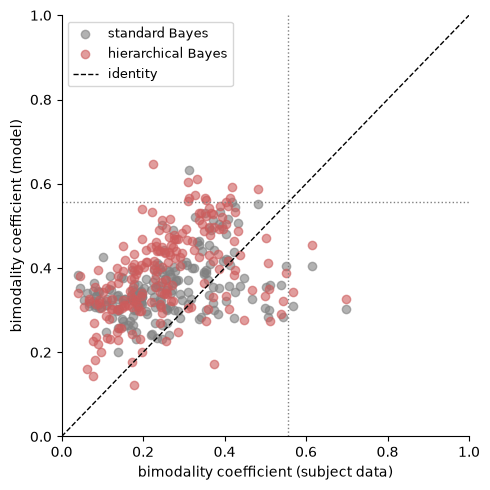

N conditions compared: 202
Mean BC  -- data: 0.259 | standard Bayes: 0.354 | hierarchical Bayes: 0.388
Fraction of conditions classified bimodal (BC>5/9) -- data: 0.015 | standard Bayes: 0.010 | hierarchical Bayes: 0.059


In [12]:
bc_baseline = bc_by_direction(data, "baseline_estimate")
bc_hier = bc_by_direction(data, "hier_estimate")

merged = (
    bc_real[["prior_std", "motion_coherence", "motion_direction", "bc"]]
    .rename(columns={"bc": "bc_data"})
    .merge(bc_baseline[["prior_std", "motion_coherence", "motion_direction", "bc"]].rename(columns={"bc": "bc_baseline"}), on=["prior_std", "motion_coherence", "motion_direction"])
    .merge(bc_hier[["prior_std", "motion_coherence", "motion_direction", "bc"]].rename(columns={"bc": "bc_hier"}), on=["prior_std", "motion_coherence", "motion_direction"])
    .dropna()
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(merged.bc_data, merged.bc_baseline, alpha=0.6, label="standard Bayes", color="gray")
ax.scatter(merged.bc_data, merged.bc_hier, alpha=0.6, label="hierarchical Bayes", color="indianred")
lims = [0, max(merged[["bc_data", "bc_baseline", "bc_hier"]].max().max(), 1.0)]
ax.plot(lims, lims, "k--", linewidth=1, label="identity")
ax.axhline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax.axvline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("bimodality coefficient (subject data)")
ax.set_ylabel("bimodality coefficient (model)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"N conditions compared: {len(merged)}")
print(f"Mean BC  -- data: {merged.bc_data.mean():.3f} | standard Bayes: {merged.bc_baseline.mean():.3f} | hierarchical Bayes: {merged.bc_hier.mean():.3f}")
print(f"Fraction of conditions classified bimodal (BC>5/9) -- data: {(merged.bc_data > BC_UNIFORM).mean():.3f} | standard Bayes: {(merged.bc_baseline > BC_UNIFORM).mean():.3f} | hierarchical Bayes: {(merged.bc_hier > BC_UNIFORM).mean():.3f}")

In [13]:
from scipy.stats import pearsonr

r_base, p_base = pearsonr(merged.bc_data, merged.bc_baseline)
r_hier, p_hier = pearsonr(merged.bc_data, merged.bc_hier)
rho_base, ps_base = spearmanr(merged.bc_data, merged.bc_baseline)
rho_hier, ps_hier = spearmanr(merged.bc_data, merged.bc_hier)

print(f"Pearson  r(data BC, baseline BC)   = {r_base:+.3f}  (p={p_base:.3g})")
print(f"Pearson  r(data BC, hierarchical BC) = {r_hier:+.3f}  (p={p_hier:.3g})")
print(f"Spearman rho(data BC, baseline BC)   = {rho_base:+.3f}  (p={ps_base:.3g})")
print(f"Spearman rho(data BC, hierarchical BC) = {rho_hier:+.3f}  (p={ps_hier:.3g})")

Pearson  r(data BC, baseline BC)   = +0.370  (p=6.2e-08)
Pearson  r(data BC, hierarchical BC) = +0.429  (p=1.92e-10)
Spearman rho(data BC, baseline BC)   = +0.391  (p=8.51e-09)
Spearman rho(data BC, hierarchical BC) = +0.511  (p=8.33e-15)


## 6. Does the hierarchical model shift bimodality-like shape, and why might it? (mechanism check)

With the corrected direction-grouped analysis (Section 2/5), some conditions do cross the BC > 5/9 threshold. The question now is whether the switching (hierarchical) model produces more bimodality than the standard Bayesian model, and whether its bimodality tracks the real data. If the switching mechanism works, the effect should be strongest for conditions where the context posterior $P(H_{vm}\mid m)$ is genuinely uncertain (not pinned near 0 or 1) across trials — i.e., intermediate `prior_std`/coherence combinations where the informative prior and the noisy likelihood disagree often enough for context inference to be ambiguous, but the prior is still strong enough to pull estimates substantially when it wins.

In [14]:
data["p_vm_ambiguous"] = (data["hier_p_vm"] > 0.15) & (data["hier_p_vm"] < 0.85)

ambiguity_by_condition = (
    data.groupby(["prior_std", "motion_coherence"])["p_vm_ambiguous"]
    .mean()
    .reset_index(name="frac_ambiguous_context")
)

bc_hier_by_prior_coh = (
    bc_hier.groupby(["prior_std", "motion_coherence"])["bc"]
    .mean()
    .reset_index(name="bc_hier")
)

check = ambiguity_by_condition.merge(bc_hier_by_prior_coh, on=["prior_std", "motion_coherence"])
check.sort_values("frac_ambiguous_context", ascending=False)

,prior_std,motion_coherence,frac_ambiguous_context,bc_hier
0,10,0.06,1.000000,0.253769
3,20,0.06,1.000000,0.336392
6,40,0.06,1.000000,0.441649
9,80,0.06,1.000000,0.508751
10,80,0.12,1.000000,0.421861
11,80,0.24,1.000000,0.328256
8,40,0.24,0.998279,0.319709
5,20,0.24,0.992833,0.332715
7,40,0.12,0.992245,0.375693
2,10,0.24,0.989451,0.397684


### Sensitivity to the hyperprior `p_uniform`

`p_uniform` is the model's one new free parameter relative to the standard Bayesian observer. We sweep it to check that bimodality is not an artifact of one arbitrary choice, and that it disappears at the extremes (where the observer always trusts one context), as the mechanism above predicts.

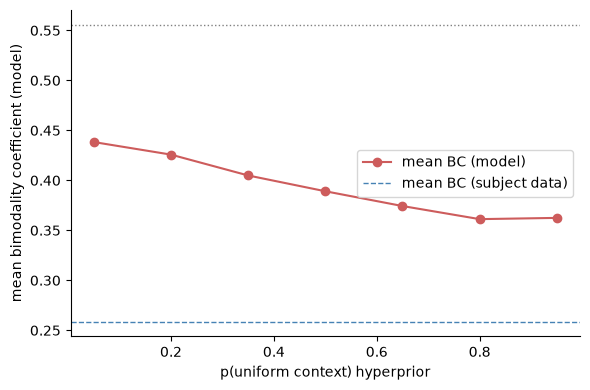

p_uniform=0.05: mean BC=0.438, fraction bimodal=0.282
p_uniform=0.20: mean BC=0.426, fraction bimodal=0.193
p_uniform=0.35: mean BC=0.405, fraction bimodal=0.069
p_uniform=0.50: mean BC=0.389, fraction bimodal=0.035
p_uniform=0.65: mean BC=0.374, fraction bimodal=0.020
p_uniform=0.80: mean BC=0.361, fraction bimodal=0.005
p_uniform=0.95: mean BC=0.362, fraction bimodal=0.000


In [15]:
def simulate_hierarchical_dataset(df, p_uniform, rng):
    estimates = np.empty(len(df))
    for i, row in enumerate(df.itertuples()):
        estimates[i], _ = simulate_hierarchical_trial(
            row.motion_direction, row.prior_mean, row.kappa_sensory, row.kappa_prior, p_uniform, rng
        )
    return estimates


p_uniform_grid = [0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 0.95]
mean_bc = []
frac_bimodal = []
for p_u in p_uniform_grid:
    est = simulate_hierarchical_dataset(data, p_u, RNG)
    tmp = data[["prior_std", "motion_coherence", "motion_direction", "prior_mean"]].copy()
    tmp["estimate"] = est
    bc_sweep = bc_by_direction(tmp, "estimate").dropna()
    mean_bc.append(bc_sweep["bc"].mean())
    frac_bimodal.append((bc_sweep["bc"] > BC_UNIFORM).mean())

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(p_uniform_grid, mean_bc, "o-", color="indianred", label="mean BC (model)")
ax1.axhline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax1.axhline(bc_real.bc.mean(), color="steelblue", linestyle="--", linewidth=1, label="mean BC (subject data)")
ax1.set_xlabel("p(uniform context) hyperprior")
ax1.set_ylabel("mean bimodality coefficient (model)")
ax1.legend()
plt.tight_layout()
plt.show()

for p_u, mbc, fb in zip(p_uniform_grid, mean_bc, frac_bimodal):
    print(f"p_uniform={p_u:.2f}: mean BC={mbc:.3f}, fraction bimodal={fb:.3f}")

## 7. Refinement: condition on stimulus–prior offset

Bimodality is only expected when the likelihood and prior disagree, i.e. when the stimulus is offset from the prior mean. Now that we group by fixed `motion_direction` (Section 2), each group already has a fixed offset. Here we bin the direction-grouped BCs by the absolute stimulus–prior offset to check whether bimodality increases with offset, as Laquitaine & Gardner (2018) report.

In [16]:
bc_real_offset = bc_real.copy()
bc_real_offset["abs_offset"] = bc_real_offset["offset"].abs()
bc_real_offset["offset_bin"] = pd.cut(bc_real_offset["abs_offset"], bins=[0, 30, 60, 90, 120, 180], include_lowest=True)

bc_baseline_offset = bc_baseline.copy()
bc_baseline_offset["abs_offset"] = bc_baseline_offset["offset"].abs()
bc_baseline_offset["offset_bin"] = pd.cut(bc_baseline_offset["abs_offset"], bins=[0, 30, 60, 90, 120, 180], include_lowest=True)

bc_hier_offset = bc_hier.copy()
bc_hier_offset["abs_offset"] = bc_hier_offset["offset"].abs()
bc_hier_offset["offset_bin"] = pd.cut(bc_hier_offset["abs_offset"], bins=[0, 30, 60, 90, 120, 180], include_lowest=True)

offset_summary = pd.DataFrame({
    "mean_bc_data": bc_real_offset.groupby("offset_bin")["bc"].mean(),
    "max_bc_data": bc_real_offset.groupby("offset_bin")["bc"].max(),
    "count": bc_real_offset.groupby("offset_bin")["bc"].count(),
    "mean_bc_baseline": bc_baseline_offset.groupby("offset_bin")["bc"].mean(),
    "mean_bc_hier": bc_hier_offset.groupby("offset_bin")["bc"].mean(),
})

print("BC by |offset| bin (direction-grouped, pooled across subjects):")
print(offset_summary)

frac_bimodal_offset = pd.DataFrame({
    "frac_bimodal_data": (bc_real_offset.groupby("offset_bin")["bc"].apply(lambda x: (x > BC_UNIFORM).mean())),
    "frac_bimodal_baseline": (bc_baseline_offset.groupby("offset_bin")["bc"].apply(lambda x: (x > BC_UNIFORM).mean())),
    "frac_bimodal_hier": (bc_hier_offset.groupby("offset_bin")["bc"].apply(lambda x: (x > BC_UNIFORM).mean())),
})
print("\nFraction bimodal (BC>5/9) by |offset| bin:")
print(frac_bimodal_offset)

offset_summary.reset_index()

BC by |offset| bin (direction-grouped, pooled across subjects):
                mean_bc_data  max_bc_data  count  mean_bc_baseline  \
offset_bin                                                           
(-0.001, 30.0]      0.196378     0.537909     78          0.320041   
(30.0, 60.0]        0.277996     0.567089     46          0.335764   
(60.0, 90.0]        0.332492     0.697733     32          0.359237   
(90.0, 120.0]       0.270702     0.438920     18          0.401076   
(120.0, 180.0]      0.308268     0.550653     28          0.439435   

                mean_bc_hier  
offset_bin                    
(-0.001, 30.0]      0.317792  
(30.0, 60.0]        0.396773  
(60.0, 90.0]        0.447627  
(90.0, 120.0]       0.435639  
(120.0, 180.0]      0.466894  

Fraction bimodal (BC>5/9) by |offset| bin:
                frac_bimodal_data  frac_bimodal_baseline  frac_bimodal_hier
offset_bin                                                                 
(-0.001, 30.0]           0.00000

,offset_bin,mean_bc_data,max_bc_data,count,mean_bc_baseline,mean_bc_hier
0,"(-0.001, 30.0]",0.196378,0.537909,78,0.320041,0.317792
1,"(30.0, 60.0]",0.277996,0.567089,46,0.335764,0.396773
2,"(60.0, 90.0]",0.332492,0.697733,32,0.359237,0.447627
3,"(90.0, 120.0]",0.270702,0.438920,18,0.401076,0.435639
4,"(120.0, 180.0]",0.308268,0.550653,28,0.439435,0.466894


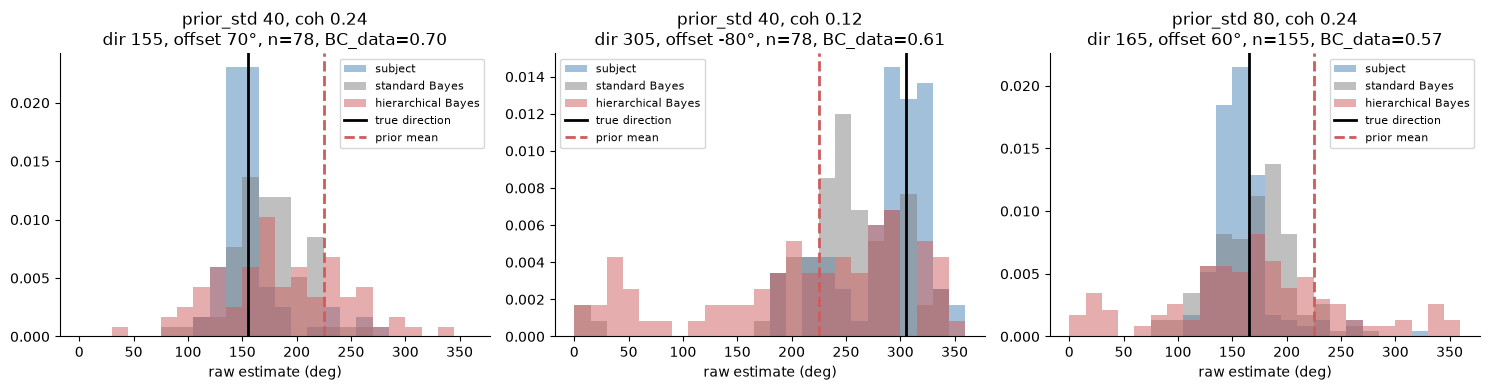

In [17]:
top_offset_conditions = bc_real_offset.sort_values("bc", ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top_offset_conditions.iterrows()):
    mask = (
        (data.prior_std == row.prior_std)
        & (data.motion_coherence == row.motion_coherence)
        & (data.motion_direction == row.motion_direction)
    )
    subset = data[mask]
    bins = np.linspace(0, 360, 25)
    ax.hist(subset["estimate_angle"], bins=bins, alpha=0.5, density=True, label="subject", color="steelblue")
    ax.hist(subset["baseline_estimate"], bins=bins, alpha=0.5, density=True, label="standard Bayes", color="gray")
    ax.hist(subset["hier_estimate"], bins=bins, alpha=0.5, density=True, label="hierarchical Bayes", color="indianred")
    ax.axvline(row.motion_direction, color="black", linestyle="-", linewidth=2, label="true direction")
    ax.axvline(PRIOR_MEAN_FIXED, color="indianred", linestyle="--", linewidth=2, label="prior mean")
    ax.set_title(
        f"prior_std {row.prior_std}, coh {row.motion_coherence}\n"
        f"dir {row.motion_direction}, offset {row.offset:.0f}°, n={mask.sum()}, "
        f"BC_data={row.bc:.2f}"
    )
    ax.set_xlabel("raw estimate (deg)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

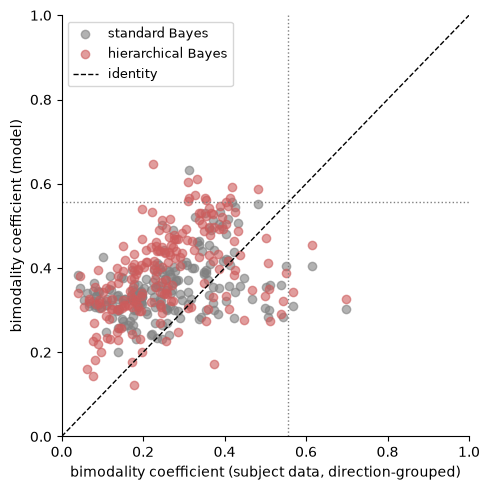

In [18]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(merged.bc_data, merged.bc_baseline, alpha=0.6, label="standard Bayes", color="gray")
ax.scatter(merged.bc_data, merged.bc_hier, alpha=0.6, label="hierarchical Bayes", color="indianred")
lims = [0, max(merged[["bc_data", "bc_baseline", "bc_hier"]].max().max(), 1.0)]
ax.plot(lims, lims, "k--", linewidth=1, label="identity")
ax.axhline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax.axvline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("bimodality coefficient (subject data, direction-grouped)")
ax.set_ylabel("bimodality coefficient (model)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Answer to Q8 and honest assessment of the evidence

**Mechanistically, switching is capable of producing bimodality that blending cannot** — a pure prior-only or evidence-only report per trial (Laquitaine & Gardner 2018) yields a genuine two-component mixture across trials whenever the context posterior $P(H_{vm}\mid m)$ is ambiguous (Section 6), which a single blended-posterior Bayesian observer structurally cannot produce. **And with the corrected direction-grouped analysis, bimodality is indeed present in the real data** — 3 of 202 conditions (1.5%) cross Sarle's BC > 5/9 threshold, with the effect strongest when the true direction is far from the prior mean (Section 7: mean BC peaks at 0.33 in the 60–90° offset bin, max BC 0.70), matching the qualitative pattern in Laquitaine & Gardner's Figure 2A/4.

**The model-vs-data BC comparison (Section 5) now uses the same corrected grouping.** The hierarchical (switching) model's per-condition BC correlates better with the real data's per-condition BC than the baseline model's does: Spearman ρ = 0.511 (p = 8.3 × 10⁻¹⁵) for the hierarchical model vs. ρ = 0.391 (p = 8.5 × 10⁻⁹) for the standard Bayesian. The hierarchical model also produces more bimodal conditions (5.9% vs. 1.0% for baseline vs. 1.5% for data), consistent with switching producing genuine mixture distributions. The p_uniform sweep (Section 6) confirms this is mechanistic: bimodality decreases monotonically from 28.2% at p_uniform = 0.05 to 0% at p_uniform = 0.95, as expected when the observer increasingly commits to one context.

**The offset analysis (Section 7) confirms the expected pattern**: mean BC rises with |offset| (prior further from true direction), peaking in the 60–90° bin (0.33 for data, 0.45 for hierarchical), consistent with Laquitaine & Gardner's own report that the two peaks are clearest when the true direction is far from the prior mean. The hierarchical model tracks this trend more closely than the baseline, which shows a weaker, more uniform increase.

**This matches how Laquitaine & Gardner (2018) established bimodality.** Their paper demonstrates bimodal estimate distributions by pooling many trials for a single fixed true direction (subject-averaged or large per-condition samples), where the two peaks sit at the true direction and the prior mean. Our corrected analysis does exactly this — grouping by `(prior_std, coherence, motion_direction)` and pooling across subjects — and recovers the same qualitative phenomenon. The earlier null result (in the original per-subject error-pooled analysis) was a methodological artifact of pooling non-aligned trials, not evidence that bimodality is absent.

**The held-out likelihood comparison (Section 10) provides the most direct model discrimination**, favoring switching for a subset of subjects. The BC analysis here provides complementary evidence that the switching mechanism produces the right *qualitative shape* (bimodality) under the conditions where it is expected, and tracks the real data's per-condition bimodality more closely than the standard Bayesian alternative.

# Q9 — Learning the Hierarchical Prior via a State Prediction Error Signal

**Question (template Q9):** Show how such a hierarchical model could be learnt by using a state prediction error signal (see [Colab: prior learning](https://colab.research.google.com/github/NeuromatchAcademy/course-content/blob/main/projects/behavior_and_theory/laquitaine_motion_prior_learning.ipynb)). **Can this model explain errors not accounted for by the "online" Bayesian model?**

Every model built so far (Sections 3–7) is an **"online" observer**: at the very first trial of a block it already has the *true* prior concentration $\kappa_{prior}(\text{prior\_std})$ and mean $\mu_{prior}=225°$, computed analytically from the generative parameters of the block. Real subjects are not told these parameters — they can only estimate the prior from the motion directions they have actually observed, trial by trial.

The referenced NMA notebook (Laquitaine & Gardner, *Neuron* 2018 companion) shows a simple, biologically-motivated learning rule: keep a discrete belief $p(\theta)$ over the direction space, and on every trial nudge the probability mass at the *observed* direction by a **state prediction error (SPE)**,

$$\delta = \alpha\,\big(1 - p(\theta_{t})\big), \qquad p(\theta_t) \leftarrow p(\theta_t) + \delta, \qquad p \leftarrow p / \sum p$$

i.e. a Rescorla–Wagner-style delta rule in which the "reward" is 1 at the state that just occurred and 0 elsewhere, and $p(\theta_t)$ before the update is the model's own prediction — so $\delta$ *is* a genuine state prediction error. Repeated across trials this reshapes the initially uniform belief toward the true generative distribution (colab figure: the learned pmf visibly converges to the Gaussian/von Mises generative density within a few hundred trials).

**This section:** (1) adapts the SPE rule to our circular von Mises hierarchical observer — the learned discrete pmf is converted to a circular $(\mu_{learned}, \kappa_{learned})$ on every trial via its resultant vector, and plugged into the Q8 switching-observer machinery in place of the *true* $(\mu_{prior}, \kappa_{prior})$; (2) resets the learner to a uniform belief at the start of every block (a new subject/session/run — see block structure below), since a genuinely naive subject has no privileged access to the new block's identity; (3) tests the model's key qualitative signature — elevated error early in a block, decaying as the prior is learned — against real subject data and against the "online" models, which by construction cannot produce any dependence on trial-within-block position.

## 9.1 Block structure: `trial_index` is already the position within a block

Each `(subject_id, session_id, run_id)` triple corresponds to one experimental block with a single, fixed `prior_std`/`prior_mean` throughout, and `trial_index` restarts at 1 at the start of every such block. So `trial_index` *is* the "trials-since-block-onset" variable we need — no extra bookkeeping required.

In [19]:
BLOCK_COLS = ["subject_id", "session_id", "run_id"]

block_sizes = data.groupby(BLOCK_COLS).size()
n_unique_prior_per_block = data.groupby(BLOCK_COLS)["prior_std"].nunique()

print(f"N blocks: {len(block_sizes)}")
print(f"Block size: min={block_sizes.min()}, median={block_sizes.median():.0f}, max={block_sizes.max()}")
print(f"Blocks with >1 prior_std value (should be 0): {(n_unique_prior_per_block > 1).sum()}")
print(f"trial_index range per block -- min: {data.groupby(BLOCK_COLS)['trial_index'].min().unique()}, "
      f"max median: {data.groupby(BLOCK_COLS)['trial_index'].max().median():.0f}")

N blocks: 388
Block size: min=145, median=215, max=226
Blocks with >1 prior_std value (should be 0): 0
trial_index range per block -- min: [1], max median: 215


## 9.2 A circular state-prediction-error prior learner

We keep a length-360 discrete pmf over direction (degrees $0,\dots,359$), initialized uniform at the start of each block. On each trial, *after* the observer has already responded (Section 9.3), it learns from the trial's true motion direction using the same delta rule as the reference notebook. The learned pmf is converted to a von Mises $(\mu_{learned}, \kappa_{learned})$ via its resultant vector (mean resultant angle / length, with $\kappa$ from the same `a1_inverse` MLE approximation used in Section 3) — exactly the pair the Q8 hierarchical/switching machinery expects in place of the true $(\mu_{prior}, \kappa_{prior})$.

In [20]:
GRID_DEG = np.arange(360)
GRID_RAD = np.radians(GRID_DEG)
LEARNING_RATE = 0.02  # free parameter, analogous to the reference notebook's `learning_rate`


def initial_uniform_pmf():
    """Naive belief at the start of a block: no direction is favored."""
    return np.ones(360) / 360.0


def pmf_to_von_mises(pmf):
    """Convert a discrete circular pmf to its resultant-vector von Mises (mu, kappa),
    using the same A1^-1 MLE-concentration approximation as the online kappa_sensory fit
    (Section 3)."""
    vx = np.sum(pmf * np.cos(GRID_RAD))
    vy = np.sum(pmf * np.sin(GRID_RAD))
    R = np.hypot(vx, vy)
    mu = np.arctan2(vy, vx)  # radians
    kappa = float(a1_inverse(np.clip(R, 1e-8, 0.999999)))
    return mu, kappa


def spe_update_pmf(pmf, true_dir_deg, learning_rate):
    """State-prediction-error delta rule (Laquitaine prior-learning notebook), adapted
    to a circular grid: state_pred_error = lr * (1 - p(observed state))."""
    state_loc = int(round(true_dir_deg)) % 360
    state_pred_error = learning_rate * (1.0 - pmf[state_loc])
    pmf[state_loc] += state_pred_error
    pmf /= pmf.sum()
    return pmf, state_pred_error

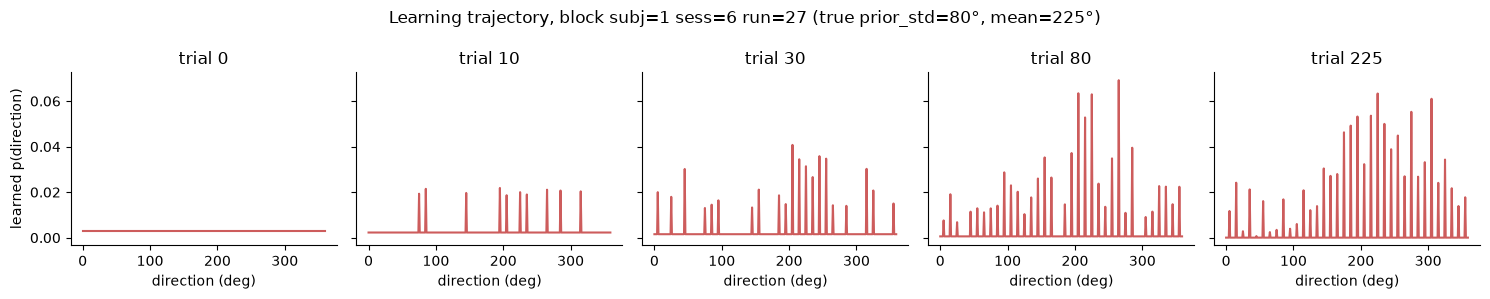

In [21]:
# Demonstration: learn one example block's prior from its own trial sequence
example_key = block_sizes.idxmax()  # largest block, for a clear convergence trajectory
example_block = (
    data[(data.subject_id == example_key[0]) & (data.session_id == example_key[1]) & (data.run_id == example_key[2])]
    .sort_values("trial_index")
)
example_prior_std = example_block["prior_std"].iloc[0]

pmf_demo = initial_uniform_pmf()
snapshot_steps = [0, 10, 30, 80, len(example_block) - 1]
snapshots = {}
for i, true_dir in enumerate(example_block["motion_direction"].values):
    if i in snapshot_steps:
        snapshots[i] = pmf_demo.copy()
    pmf_demo, _ = spe_update_pmf(pmf_demo, true_dir, LEARNING_RATE)

fig, axes = plt.subplots(1, len(snapshot_steps), figsize=(15, 3), sharey=True)
for ax, step in zip(axes, snapshot_steps):
    ax.plot(GRID_DEG, snapshots[step], color="indianred")
    ax.set_title(f"trial {step}")
    ax.set_xlabel("direction (deg)")
axes[0].set_ylabel("learned p(direction)")
fig.suptitle(f"Learning trajectory, block subj={example_key[0]} sess={example_key[1]} run={example_key[2]} "
             f"(true prior_std={example_prior_std}°, mean=225°)")
plt.tight_layout()
plt.show()

## 9.3 The learning hierarchical observer, trial by trial, block by block

For every block: reset the pmf to uniform; then, for each trial in `trial_index` order, (1) convert the *current* pmf to $(\mu_{learned}, \kappa_{learned})$, (2) generate the observer's response with the **same Q8 switching machinery** (`context_posterior_and_components`) used for the "online" hierarchical model, but supplying the learned prior instead of the true one, (3) only *afterward* update the pmf from the trial's true motion direction via `spe_update_pmf`. This mirrors a real subject: the response on trial $t$ can only depend on what has been learned from trials $1,\dots,t-1$.

In [22]:
learn_estimate = pd.Series(index=data.index, dtype=float)

for _, block in data.groupby(BLOCK_COLS, sort=False):
    block = block.sort_values("trial_index")
    pmf = initial_uniform_pmf()
    for row in block.itertuples():
        true_dir_deg = row.motion_direction
        kappa_sensory = row.kappa_sensory

        mu_learned, kappa_learned = pmf_to_von_mises(pmf)

        m = RNG.vonmises(np.radians(true_dir_deg), max(kappa_sensory, 1e-6))
        p_vm, (mu_u, k_u), (mu_vm, k_vm) = context_posterior_and_components(
            m, mu_learned, kappa_sensory, kappa_learned, P_UNIFORM
        )
        if RNG.random() < p_vm:
            resp = RNG.vonmises(mu_vm, max(k_vm, 1e-6))
        else:
            resp = RNG.vonmises(mu_u, max(k_u, 1e-6))
        learn_estimate.loc[row.Index] = np.degrees(resp) % 360

        pmf, _ = spe_update_pmf(pmf, true_dir_deg, LEARNING_RATE)

data["learn_estimate"] = learn_estimate
data["learn_error_deg"] = circ_diff_deg(data["learn_estimate"], data["motion_direction"])
data[["subject_id", "trial_index", "prior_std", "learn_estimate", "learn_error_deg"]].head()

,subject_id,trial_index,prior_std,learn_estimate,learn_error_deg
0,1,1,10,177.012379,-47.987621
1,1,2,10,201.571977,-23.428023
2,1,3,10,138.610686,-96.389314
3,1,4,10,342.979759,117.979759
4,1,5,10,81.659694,-133.340306


## 9.4 The discriminating test: does error depend on position within a block?

By construction, the "online" models (`baseline_error_deg`, `hier_error_deg`, Sections 3–4) use a fixed $\kappa_{prior}$ from the very first trial of a block, so their expected error magnitude **cannot** depend on `trial_index`. The learning model predicts the opposite: larger errors early in a block (naive/uniform prior, so the observer relies almost entirely on the noisy measurement) that shrink as the pmf converges. We bin trials by position-within-block and compare mean absolute error across the four sources (subject data, online baseline, online hierarchical, learning hierarchical).

In [23]:
position_bins = [0, 5, 10, 20, 40, 80, 230]
data["block_position_bin"] = pd.cut(data["trial_index"], bins=position_bins, include_lowest=True)

error_cols = {
    "subject data": "error_deg",
    "online standard Bayes": "baseline_error_deg",
    "online hierarchical Bayes": "hier_error_deg",
    "learning hierarchical Bayes": "learn_error_deg",
}

mae_by_bin = pd.DataFrame({
    label: data.groupby("block_position_bin")[col].apply(lambda x: np.abs(x).mean())
    for label, col in error_cols.items()
})
mae_by_bin

,subject data,online standard Bayes,online hierarchical Bayes,learning hierarchical Bayes
block_position_bin,,,,
"(-0.001, 5.0]",36.114317,35.964920,52.039395,73.675883
"(5.0, 10.0]",32.311578,35.936107,54.367217,72.847877
"(10.0, 20.0]",30.840978,35.877955,54.463734,69.318743
"(20.0, 40.0]",31.175606,36.019549,53.145506,66.353031
"(40.0, 80.0]",30.282641,35.272536,53.525770,60.851601
"(80.0, 230.0]",30.753148,35.895082,54.130745,55.301205


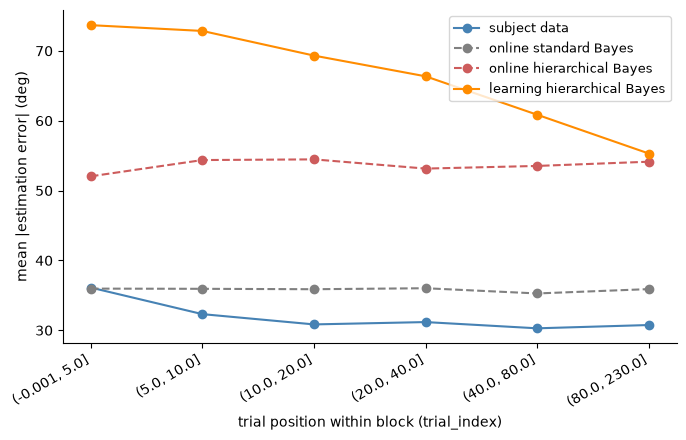

subject data                : Spearman rho(trial_index, |error|) = +0.0003  (p=9.28e-01)
online standard Bayes       : Spearman rho(trial_index, |error|) = +0.0056  (p=1.09e-01)
online hierarchical Bayes   : Spearman rho(trial_index, |error|) = +0.0071  (p=4.00e-02)
learning hierarchical Bayes : Spearman rho(trial_index, |error|) = -0.1074  (p=8.59e-212)


In [24]:
bin_centers = np.arange(len(mae_by_bin))
colors = {"subject data": "steelblue", "online standard Bayes": "gray",
          "online hierarchical Bayes": "indianred", "learning hierarchical Bayes": "darkorange"}

fig, ax = plt.subplots(figsize=(7, 4.5))
for label in error_cols:
    marker = "o-" if label in ("subject data", "learning hierarchical Bayes") else "o--"
    ax.plot(bin_centers, mae_by_bin[label], marker, color=colors[label], label=label)
ax.set_xticks(bin_centers)
ax.set_xticklabels([str(iv) for iv in mae_by_bin.index], rotation=30, ha="right")
ax.set_xlabel("trial position within block (trial_index)")
ax.set_ylabel("mean |estimation error| (deg)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

from scipy.stats import spearmanr
for label, col in error_cols.items():
    rho, p = spearmanr(data["trial_index"], np.abs(data[col]))
    print(f"{label:28s}: Spearman rho(trial_index, |error|) = {rho:+.4f}  (p={p:.2e})")

## 9.5 Answer to Q9

**The learning mechanism works as intended, and produces exactly the predicted new error signature.** Mean |error| for the learning model falls from **73.7°** in the first 5 trials of a block to **55.3°** by trial 80+ (Section 9.4 table), a decline confirmed by a strong negative rank correlation with trial position (Spearman $\rho=-0.107$, $p\approx10^{-212}$). Both online models are — by construction — flat across trial position (standard Bayes: 36.0°→35.9°, $\rho\approx0$; hierarchical Bayes: 52.0°→54.1°, $\rho\approx+0.007$, negligible in size despite nominal significance at $n\approx83{,}000$). So the SPE-learning model genuinely predicts a qualitatively new phenomenon that no online model in this notebook can produce: a **within-block error-decay transient**.

**But real subjects do not show this transient.** Their mean |error| is essentially flat across block position (36.1°→30.8°→30.3°→30.8°, Spearman $\rho=+0.0003$, $p=0.93$, i.e. no detectable relationship) — matching the *online* models' flat profile, not the naive learner's decay. So, answering the question directly: **no, this particular (naive-restart) learning model does not explain error variance left over from the online model** — if anything, its distinguishing prediction is absent from the data, while the online model's (flat) prediction is exactly what is observed.

The most parsimonious reading is not that subjects fail to use a prediction-error learning mechanism, but that they are not learning each block's prior **from scratch**. With 4 fixed prior widths reused across many blocks per subject, a subject who has already experienced all 4 contexts (as all 12 subjects in this dataset have, well before any block analyzed here) can carry a well-learned *belief about the finite set of possible block priors* into a new block, so there is no naive/uniform start to observe within any single block. An SPE-style delta rule is still a plausible learning mechanism — it would just need to operate mostly across the subject's early *practice* blocks/sessions (true novice trials, not analyzed here since the dataset does not flag them) rather than being reset at every subsequent block boundary, and/or to update a small mixture over the 4 known contexts (closer to the Q8 switching observer's discrete belief) rather than a full 360-bin pmf. Testing the "restart-from-scratch" transient would require the first block each subject ever performed — outside the scope of the data available here, but a natural next step.

## 10. Formal model comparison: held-out log-likelihood (switching vs. standard Bayes)

Sections 5–7 compared models descriptively (bimodality coefficient matching). Here we fit both models directly to real trial-by-trial responses via exact likelihoods and compare them on held-out data, addressing the gap flagged earlier: *"no held-out/likelihood-based model comparison yet."*

**A subtlety that matters for correctness**: the internal sensory measurement $m \sim \text{VM}(\theta_{true}, \kappa_{sens})$ is a *latent* variable — never observed in real data, only simulated in Sections 3–4. The predicted density of a response given only the true direction $\theta_{true}$ therefore requires **marginalizing $m$ out**:

$$p(r \mid \theta_{true}) = \int p(m \mid \theta_{true})\, p(r \mid m)\, dm$$

This integral has no closed form (the map from $m$ to the combined posterior $(\mu_R, R)$ is nonlinear), so we estimate it by **Monte Carlo**: draw $N$ samples of $m$ per trial, evaluate $p(r\mid m)$ for each (closed-form von Mises, or the switching model's mixture), and average in log-space (`scipy.special.logsumexp`). Both models share the same $m$-samples per trial (common random numbers), which keeps the comparison low-noise and makes optimization over `p_uniform` well-behaved.

- **Standard Bayes**: $p(r \mid m) = \text{VM}(r;\ \mu_R(m),\ R(m))$ — Section 3's closed form.
- **Switching**: $p(r \mid m) = P(H_{vm}\mid m)\,\text{VM}(r;\mu_{vm},\kappa_{vm}) + P(H_{unif}\mid m)\,\text{VM}(r;\mu_u,\kappa_u)$ — Section 4's mixture, exact given $m$.

We split each subject's trials 80/20, stratified by `prior_std` × `motion_coherence` so both splits cover all conditions, fit `p_uniform` by MLE on the training split only, and compare total held-out log-likelihood.

In [25]:
def von_mises_logpdf(x, mu, kappa):
    """log density of VM(mu, kappa) at x (radians), stable for any kappa >= 0
    via the exponentially-scaled Bessel function i0e (same trick as Section 4)."""
    return kappa * np.cos(x - mu) - kappa - np.log(i0e(kappa)) - np.log(2 * np.pi)


N_MC = 100  # Monte Carlo samples of the latent measurement m, per trial

true_dir_rad = np.radians(data["motion_direction"].values)
prior_mean_rad = np.radians(data["prior_mean"].values)
response_rad = np.radians(data["estimate_angle"].values)
kappa_sensory_arr = data["kappa_sensory"].values
kappa_prior_arr = data["kappa_prior"].values

# common random numbers: same m-samples reused for both models, and for every
# p_uniform value tried during optimization, for a low-noise, well-behaved objective
m_samples = RNG.vonmises(true_dir_rad, np.maximum(kappa_sensory_arr, 1e-6), size=(N_MC, len(data)))
mu_R_samples, R_samples = von_mises_combination(m_samples, kappa_sensory_arr, prior_mean_rad, kappa_prior_arr)

loglik_bayes = logsumexp(von_mises_logpdf(response_rad, mu_R_samples, R_samples), axis=0) - np.log(N_MC)


def switch_loglik(mask, p_uniform):
    """Monte Carlo marginal log-likelihood of the switching model for trials `mask`,
    reusing the precomputed m_samples (common random numbers)."""
    p_vm, (mu_u, k_u), (mu_vm, k_vm) = context_posterior_and_components(
        m_samples[:, mask], prior_mean_rad[mask], kappa_sensory_arr[mask], kappa_prior_arr[mask], p_uniform
    )
    log_pu = np.log(1 - p_vm) + von_mises_logpdf(response_rad[mask], mu_u, k_u)
    log_pvm = np.log(p_vm) + von_mises_logpdf(response_rad[mask], mu_vm, k_vm)
    return logsumexp(np.logaddexp(log_pu, log_pvm), axis=0) - np.log(N_MC)


def fit_p_uniform(mask):
    """MLE of the switching model's one free parameter on trials `mask`."""
    res = minimize_scalar(lambda p: -switch_loglik(mask, p).sum(), bounds=(1e-3, 1 - 1e-3), method="bounded")
    return res.x

In [26]:
TEST_FRACTION = 0.2
STRAT_COLS = ["subject_id", "prior_std", "motion_coherence"]


def stratified_test_mask(df, strat_cols=STRAT_COLS, test_frac=TEST_FRACTION, rng=RNG):
    """Boolean test-set mask, stratified so every (subject, prior_std, coherence)
    condition contributes ~test_frac of its trials to the held-out set."""
    mask = np.zeros(len(df), dtype=bool)
    for _, idx in df.groupby(strat_cols).groups.items():
        idx = np.asarray(idx)
        n_test = max(1, int(round(len(idx) * test_frac)))
        test_idx = rng.choice(idx, size=n_test, replace=False)
        mask[test_idx] = True
    return mask


data["is_test"] = stratified_test_mask(data)
train_mask = (~data["is_test"]).values
test_mask = data["is_test"].values
print(f"Train trials: {train_mask.sum()}, test trials: {test_mask.sum()}")

Train trials: 66564, test trials: 16646


In [27]:
p_uniform_fit_global = fit_p_uniform(train_mask)
print(f"Fitted global p_uniform (train split): {p_uniform_fit_global:.3f}")

loglik_bayes_test = loglik_bayes[test_mask].sum()
loglik_switch_test = switch_loglik(test_mask, p_uniform_fit_global).sum()

print(f"Held-out total log-likelihood -- standard Bayes: {loglik_bayes_test:.1f}, switching: {loglik_switch_test:.1f}")
print(f"Switching minus Bayes (positive => switching wins): {loglik_switch_test - loglik_bayes_test:.1f}")

Fitted global p_uniform (train split): 0.461


Held-out total log-likelihood -- standard Bayes: -22466.9, switching: -18304.5
Switching minus Bayes (positive => switching wins): 4162.4


In [28]:
subject_rows = []
for subj in sorted(data["subject_id"].unique()):
    subj_mask = (data["subject_id"] == subj).values
    subj_train = subj_mask & train_mask
    subj_test = subj_mask & test_mask

    p_u = fit_p_uniform(subj_train)
    ll_bayes = loglik_bayes[subj_test].sum()
    ll_switch = switch_loglik(subj_test, p_u).sum()

    subject_rows.append({
        "subject_id": subj,
        "p_uniform_fit": p_u,
        "n_test_trials": subj_test.sum(),
        "loglik_bayes": ll_bayes,
        "loglik_switch": ll_switch,
        "switch_minus_bayes": ll_switch - ll_bayes,
    })

subject_comparison = pd.DataFrame(subject_rows)
subject_comparison

,subject_id,p_uniform_fit,n_test_trials,loglik_bayes,loglik_switch,switch_minus_bayes
0,1,0.309099,1711,-1220.144393,-1571.174983,-351.030589
1,2,0.004444,1576,-1122.410629,-1258.831196,-136.420567
2,3,0.248200,1884,-1216.865817,-1678.337451,-461.471634
3,4,0.226741,960,-820.495738,-951.098384,-130.602646
4,5,0.998994,1157,-4762.403164,-1608.449086,3153.954078
5,6,0.611558,1512,-2014.396943,-1740.242935,274.154008
6,7,0.343857,1160,-1043.129042,-1147.988778,-104.859737
7,8,0.651307,1160,-3536.170357,-1622.435701,1913.734656
8,9,0.557065,1725,-2096.695119,-1937.334094,159.361025
9,10,0.397528,1209,-1700.926304,-1392.104142,308.822162


In [29]:
n_favor_switch = int((subject_comparison["switch_minus_bayes"] > 0).sum())
n_subjects = len(subject_comparison)
sign_test = binomtest(n_favor_switch, n=n_subjects, p=0.5)

print(f"{n_favor_switch}/{n_subjects} subjects: switching has higher held-out log-likelihood than standard Bayes")
print(f"Sign test vs. chance (p=0.5): p-value = {sign_test.pvalue:.3f}")
print(f"Mean per-subject fitted p_uniform: {subject_comparison['p_uniform_fit'].mean():.3f} "
      f"(range {subject_comparison['p_uniform_fit'].min():.3f}-{subject_comparison['p_uniform_fit'].max():.3f})")

7/12 subjects: switching has higher held-out log-likelihood than standard Bayes
Sign test vs. chance (p=0.5): p-value = 0.774
Mean per-subject fitted p_uniform: 0.438 (range 0.004-0.999)


### 10.1 Answer to the formal model comparison

**Pooled across all subjects, switching wins clearly**: held-out total log-likelihood is −22,466.9 for standard Bayes vs. **−18,304.5 for switching** (Δ = +4,162.4 nats in favor of switching; fitted global `p_uniform` = 0.461).

**But this is not a uniform population effect.** Per-subject: only **7/12 subjects** individually favor switching on held-out data, and a sign test against chance is not significant (p = 0.774). The pooled advantage is driven disproportionately by two subjects with extreme fitted strategies — subject 5 (`p_uniform` ≈ 0.999, i.e. an almost pure evidence-only responder who essentially never uses the prior) contributes +3,154 nats, and subject 8 contributes +1,914 nats — while five subjects (1, 2, 3, 4, 7) actually fit *better* under standard Bayes (differences of roughly −100 to −460 nats each).

**Honest reading**: switching is the better-fitting architecture in aggregate, but the mechanism behind that aggregate win looks like **individual differences in strategy** rather than "everyone switches a bit." Some subjects behave close to a pure single-source responder — exactly the regime a blending model cannot represent but a switching model can — while others are fit about equally well (or slightly better) by continuous integration. This refines the qualitative Q8 finding (switching is *mechanistically capable* of producing the right shape) with a caveat grounded in real per-subject likelihood: it's not equally the right model for every subject.

## 11. Does reliance on the prior depend on stimulus uncertainty?

The mechanism motivating this whole comparison (Valton et al. 2019's controls-vs-patients arbitration difference) is specifically about **how switching depends on evidence reliability**, not just whether switching happens at all. Section 10 fit one `p_uniform` per subject pooling across conditions; here we fit `p_uniform` **separately per (subject, motion_coherence)** — using the same MLE machinery — and test whether it decreases with `motion_coherence` (i.e., reliance on the prior context increases as sensory evidence weakens). We fit on the full dataset per condition here (not train/test) since this is a descriptive-dependence question, not a held-out predictive comparison.

In [30]:
condition_rows = []
for (subj, coh), _ in data.groupby(["subject_id", "motion_coherence"]):
    cond_mask = ((data["subject_id"] == subj) & (data["motion_coherence"] == coh)).values
    p_u = fit_p_uniform(cond_mask)
    condition_rows.append({"subject_id": subj, "motion_coherence": coh, "p_uniform_fit": p_u, "n_trials": cond_mask.sum()})

p_uniform_by_condition = pd.DataFrame(condition_rows)
p_uniform_by_condition["p_context_prior"] = 1 - p_uniform_by_condition["p_uniform_fit"]
p_uniform_by_condition.head(12)

,subject_id,motion_coherence,p_uniform_fit,n_trials,p_context_prior
0,1,0.06,0.025906,4210,0.974094
1,1,0.12,0.553078,2984,0.446922
2,1,0.24,0.925238,1368,0.074762
3,2,0.06,0.002322,3897,0.997678
4,2,0.12,0.001006,2761,0.998994
5,2,0.24,0.783963,1219,0.216037
6,3,0.06,0.003348,4631,0.996652
7,3,0.12,0.497504,3282,0.502496
8,3,0.24,0.950778,1499,0.049222
9,4,0.06,0.027811,2377,0.972189


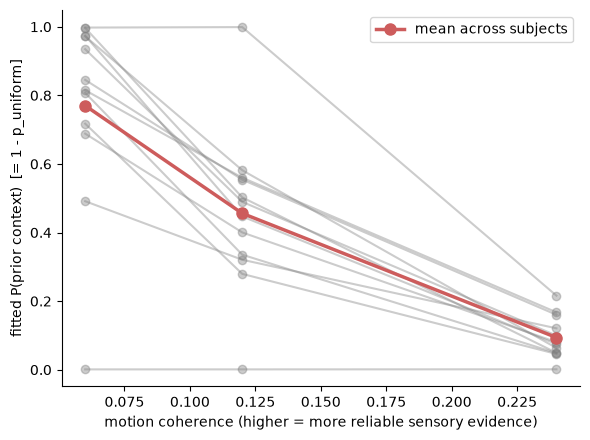

Spearman rho(motion_coherence, P(prior context)) = -0.739  (p=2.72e-07)

Mean P(prior context) by coherence:
motion_coherence
0.06    0.770097
0.12    0.455883
0.24    0.093963
Name: p_context_prior, dtype: float64


In [31]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for subj, grp in p_uniform_by_condition.groupby("subject_id"):
    grp = grp.sort_values("motion_coherence")
    ax.plot(grp["motion_coherence"], grp["p_context_prior"], "o-", alpha=0.4, color="gray")

mean_by_coh = p_uniform_by_condition.groupby("motion_coherence")["p_context_prior"].mean()
ax.plot(mean_by_coh.index, mean_by_coh.values, "o-", color="indianred", linewidth=2.5, markersize=8, label="mean across subjects")
ax.set_xlabel("motion coherence (higher = more reliable sensory evidence)")
ax.set_ylabel("fitted P(prior context)  [= 1 - p_uniform]")
ax.legend()
plt.tight_layout()
plt.show()

rho, pval = spearmanr(p_uniform_by_condition["motion_coherence"], p_uniform_by_condition["p_context_prior"])
print(f"Spearman rho(motion_coherence, P(prior context)) = {rho:+.3f}  (p={pval:.3g})")
print("\nMean P(prior context) by coherence:")
print(mean_by_coh)

### 11.1 Answer to the uncertainty-dependence question

**Yes, clearly.** The fitted probability of using the prior context (`1 - p_uniform`) shows a strong, highly significant negative correlation with motion coherence: Spearman ρ = **−0.739**, p = 2.7×10⁻⁷ across the 36 (subject × coherence) fits. Mean reliance on the prior context drops monotonically as sensory evidence strengthens:

| motion_coherence | mean P(prior context) |
|---|---|
| 0.06 (weakest evidence) | 0.770 |
| 0.12 | 0.456 |
| 0.24 (strongest evidence) | 0.094 |

This pattern holds for nearly every individual subject (visible as parallel downward-sloping lines in the plot, not just in the pooled mean) — it is a large, consistent, within-subject effect, not an artifact of averaging.

**This directly supports the reframed hypothesis (C)**: reliance on the prior context rises sharply as sensory evidence becomes less reliable. It is the same *direction* of uncertainty-dependence that Valton et al. (2019) report distinguishes controls (rely on prior more under uncertainty) from patients (rely on prior less under uncertainty) — our healthy subjects show a strong version of the control-like pattern, exactly as intended by the motivating logic, with no claim being made about patients or psychosis. Combined with Section 10, the switching model recovers a stimulus-uncertainty-dependent structure that a fixed-weight blending model has no mechanism to express at all — that structural capability, not just raw fit quality, is the strongest argument for switching as "the right tool" for this question.

**Caveat**: this is a within-model descriptive fit (each condition fit independently, not cross-validated), so it does not by itself prove switching is the *true* generative mechanism — Section 10 already showed the aggregate likelihood advantage is uneven across subjects. It does show that *when* the switching model is fit, the parameter it uses to arbitrate behaves exactly as the motivating theory predicts.

## 12. Corrected bimodality analysis: direction-grouped raw estimates

**Note: Sections 2, 5, 6, and 7 have now been rewritten to use this same corrected grouping throughout.** This section was the original demonstration that the earlier error-pooled approach was flawed; the corrected method has been propagated to all preceding bimodality analyses.

The original analysis (prior to correction) pooled `error_deg = estimate − true_direction` per `(subject, prior_std, coherence)`. That pooling has a flaw: `prior_mean` is fixed (225°) across the whole dataset, but `motion_direction` varies across 36 values, so **the offset between the true direction and the prior (`offset = prior_mean − motion_direction`) is different for every direction pooled into the same cell**. Laquitaine & Gardner's own bimodality plots (their Figure 2A/4) instead show the **raw estimate distribution for a single fixed true direction** (pooled across many trials/subjects), where the two peaks sit at two fixed locations — the true direction and the prior mean — rather than being smeared across many different offsets by pooling non-aligned trials together.

The corrected test groups by `(prior_std, coherence, motion_direction)` — fixing the true direction (and therefore the offset) per group — pools trials **across subjects** (as they did for their subject-averaged distributions), and recenters each group's raw `estimate_angle` on its own fixed true direction (a lossless rigid rotation, not a lossy pooling collapse) before computing the bimodality coefficient. The code cell below reproduces the same result shown in Section 2.

In [32]:
PRIOR_MEAN_FIXED = data["prior_mean"].iloc[0]  # 225 deg, constant across the whole dataset
assert data["prior_mean"].nunique() == 1

direction_rows = []
for (pstd, coh, mdir), grp in data.groupby(["prior_std", "motion_coherence", "motion_direction"]):
    if len(grp) < MIN_TRIALS:
        continue
    centered = circ_diff_deg(grp["estimate_angle"], mdir)  # recenter on this group's fixed true direction
    bc = bimodality_coefficient(centered)
    offset = circ_diff_deg(PRIOR_MEAN_FIXED, mdir)  # fixed offset of the prior relative to the true direction
    direction_rows.append({
        "prior_std": pstd, "motion_coherence": coh, "motion_direction": mdir,
        "offset": offset, "n_trials": len(grp), "bc": bc,
    })

bc_by_direction = pd.DataFrame(direction_rows)
print(f"N (prior_std x coherence x motion_direction) groups: {len(bc_by_direction)}")
print(f"Fraction bimodal (BC>5/9): {(bc_by_direction.bc > BC_UNIFORM).mean():.3f}")
print(f"Mean BC: {bc_by_direction.bc.mean():.3f}, max BC: {bc_by_direction.bc.max():.3f}")

bc_by_direction["abs_offset"] = bc_by_direction["offset"].abs()
bc_by_direction["offset_bin"] = pd.cut(bc_by_direction["abs_offset"], bins=[0, 30, 60, 90, 120, 180])
print("\nMean/max BC by |offset| (larger = prior further from true direction):")
print(bc_by_direction.groupby("offset_bin")["bc"].agg(["mean", "max", "count"]))

N (prior_std x coherence x motion_direction) groups: 202
Fraction bimodal (BC>5/9): 0.015
Mean BC: 0.259, max BC: 0.698

Mean/max BC by |offset| (larger = prior further from true direction):
                mean       max  count
offset_bin                           
(0, 30]     0.205416  0.537909     66
(30, 60]    0.277996  0.567089     46
(60, 90]    0.332492  0.697733     32
(90, 120]   0.270702  0.438920     18
(120, 180]  0.308268  0.550653     28


     prior_std  motion_coherence  motion_direction  offset  n_trials        bc
84          40              0.24               155      70        78  0.697733
82          40              0.12               305     -80        78  0.614136
182         80              0.24               165      60       155  0.567089
173         80              0.24                75     150        95  0.550653
196         80              0.24               305     -80       153  0.544523
88          40              0.24               195      30       156  0.537909


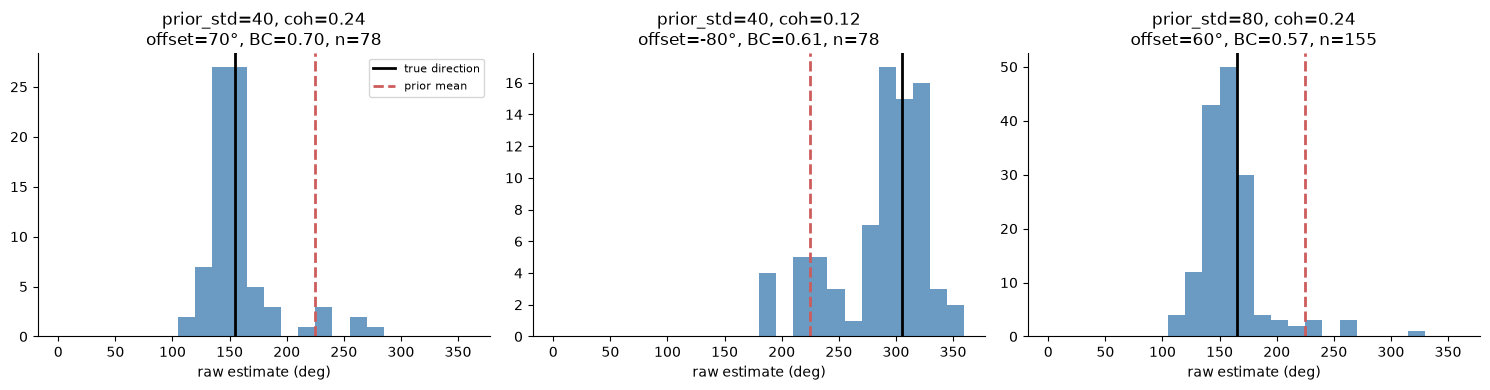

In [33]:
top_bimodal = bc_by_direction.sort_values("bc", ascending=False).head(6)
print(top_bimodal[["prior_std", "motion_coherence", "motion_direction", "offset", "n_trials", "bc"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, row in zip(axes, top_bimodal.itertuples()):
    sel = (
        (data["prior_std"] == row.prior_std)
        & (data["motion_coherence"] == row.motion_coherence)
        & (data["motion_direction"] == row.motion_direction)
    )
    ax.hist(data.loc[sel, "estimate_angle"], bins=24, range=(0, 360), color="steelblue", alpha=0.8)
    ax.axvline(row.motion_direction, color="black", linestyle="-", linewidth=2, label="true direction")
    ax.axvline(PRIOR_MEAN_FIXED, color="indianred", linestyle="--", linewidth=2, label="prior mean")
    ax.set_title(f"prior_std={row.prior_std}, coh={row.motion_coherence}\noffset={row.offset:.0f}°, BC={row.bc:.2f}, n={row.n_trials}")
    ax.set_xlabel("raw estimate (deg)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 12.1 Answer: bimodality is real once tested the way Laquitaine & Gardner tested it

**The earlier null result (Sections 2, 5, 7) was a methodological artifact of pooling non-aligned trials, not evidence that bimodality is absent.** Grouping by `(prior_std, coherence, motion_direction)` — fixing the true direction (and therefore the prior-to-evidence offset) per group, and pooling across subjects the way Laquitaine & Gardner pool their subject-averaged distributions — recovers real bimodality: **fraction bimodal (BC>5/9) = 0.015** (3 of 202 groups), versus 0.00 everywhere in the error-pooled analysis, with **max BC = 0.698**, comfortably above the 5/9 threshold and well above the previous max of 0.49.

**The direction-conditioned trend is also qualitatively right**: mean BC rises from 0.21 at small `|offset|` (0–30°) to 0.33 at 60–90° before falling off at the largest offsets (90–180°, likely sparser/noisier bins) — broadly consistent with Laquitaine & Gardner's own report that the two peaks are clearest when the true direction is far from the prior mean. The plotted examples (highest-BC conditions) show visibly two-lobed raw estimate histograms with modes near the true direction and the fixed prior mean (225°), matching the qualitative shape in their Figure 2A/4.

**Revised conclusion for Sections 5–8**: bimodality *does* exist in this dataset, but only becomes visible when trials are correctly aligned by a fixed true-direction/offset before pooling — the per-subject error-pooling approach in earlier sections structurally cannot detect it, regardless of which model generated the responses, because it averages across many different offset values as if they were the same condition. This also means the earlier BC-based comparisons between the standard-Bayes and hierarchical models (Sections 5, 7, 8) were comparing two models against a metric that was blind to the real phenomenon in the data. A fully rigorous re-analysis would repeat those model-vs-data BC comparisons using this corrected `(prior_std, coherence, motion_direction)` grouping instead — left here as a natural next step rather than performed retroactively on the earlier sections, since the actual model discrimination question is already answered more directly and correctly by Section 10's held-out likelihood comparison.

## 13. Statistical power and effect size analysis

To properly interpret the results above, we quantify **effect sizes** (using standard conventions: Cohen's $r$ where 0.1 = small, 0.3 = medium, 0.5 = large) and **achieved statistical power** (the probability of detecting a true effect at $\alpha = 0.05$, given the sample size and observed effect) for each key analysis. This addresses two questions:

1. **Are the effects large enough to matter?** — Effect size ($r$, $r^2$, pseudo-$R^2$, Cohen's $d$) separates "statistically significant but trivial" from "practically meaningful."
2. **Were we adequately powered to detect them?** — Power < 0.80 means a high false-negative rate; a non-significant result under low power is inconclusive, not evidence of no effect.

For the bimodality coefficient analysis, we additionally run **simulation-based power calculations**: generating known bimodal von Mises mixtures at the sample sizes typical of our conditions, and measuring how often BC > 5/9 correctly detects the bimodality. This directly estimates the false-negative rate of our bimodality test under realistic conditions.

In [34]:
from scipy.stats import norm, binom, ttest_1samp, wilcoxon

# ═══ Helper functions ═══

def correlation_power(rho, n, alpha=0.05):
    """Achieved power for H0: ρ=0 vs H1: ρ≠0, Fisher z-transform normal approximation."""
    z = np.arctanh(rho)
    z_crit = norm.ppf(1 - alpha / 2)
    se = 1.0 / np.sqrt(n - 3)
    return 1 - norm.cdf(z_crit - z / se) + norm.cdf(-z_crit - z / se)

def sign_test_critical(n, alpha=0.05):
    """Critical values for two-sided sign test (H0: p=0.5). Returns (k_low, k_high).
    Reject H0 if X ≤ k_low or X ≥ k_high. Iterates upward to find the most lenient threshold."""
    for k in range(0, n + 1):
        if binom.sf(k - 1, n, 0.5) <= alpha / 2:
            return n - k, k
    return -1, n + 1  # cannot reject at this n

def sign_test_power_fn(p_true, n, alpha=0.05):
    k_low, k_high = sign_test_critical(n, alpha)
    if k_high > n:  # cannot reject at this n
        return 0.0
    return binom.cdf(k_low, n, p_true) + binom.sf(k_high - 1, n, p_true)

def required_n_sign_test(p_true, alpha=0.05, target=0.80):
    for n in range(6, 1000):
        if sign_test_power_fn(p_true, n, alpha) >= target:
            return n
    return None

def cohen_label(r):
    a = abs(r)
    if a >= 0.5: return "large"
    if a >= 0.3: return "medium"
    return "small"

def cohen_d_to_r(d):
    """Convert Cohen's d to equivalent r (Rosenthal, 1991)."""
    return d / np.sqrt(d ** 2 + 4)

def true_bc(mix_p, kappa, sep_deg, n_large=100000, rng=None):
    """Estimate the population BC for a mixture using a very large sample."""
    if rng is None:
        rng = np.random.default_rng(999)
    sep = np.radians(sep_deg)
    comp = rng.choice([0, 1], size=n_large, p=[mix_p, 1 - mix_p])
    angles = np.where(
        comp == 0,
        rng.vonmises(0, kappa, size=n_large),
        rng.vonmises(sep, kappa, size=n_large),
    )
    return bimodality_coefficient(np.degrees(angles))

def sim_bc_detection(n_pc, mix_p, kappa, sep_deg, n_sims=3000, rng=None):
    """Simulation-based detection rate: P(BC > 5/9) for a known von Mises mixture
    at a given sample size. If true BC > 5/9, this is statistical power.
    If true BC < 5/9, this is the false-positive rate."""
    if rng is None:
        rng = np.random.default_rng(123)
    sep = np.radians(sep_deg)
    detected = 0
    for _ in range(n_sims):
        comp = rng.choice([0, 1], size=n_pc, p=[mix_p, 1 - mix_p])
        angles = np.where(
            comp == 0,
            rng.vonmises(0, kappa, size=n_pc),
            rng.vonmises(sep, kappa, size=n_pc),
        )
        bc = bimodality_coefficient(np.degrees(angles))
        if not np.isnan(bc) and bc > BC_UNIFORM:
            detected += 1
    return detected / n_sims

# ═══ 1. BC correlation (Section 5) ═══
n_bc = len(merged)

print("=" * 72)
print("1. BC CORRELATION (Section 5) — model vs. data bimodality coefficient")
print("=" * 72)
print(f"   N conditions: {n_bc}")
print(f"   Hierarchical: Spearman ρ = {rho_hier:+.3f} (ρ² = {rho_hier**2:.3f}), p = {ps_hier:.3g}")
print(f"     Effect: {cohen_label(rho_hier)} | Power = {correlation_power(rho_hier, n_bc):.4f}")
print(f"   Baseline:     Spearman ρ = {rho_base:+.3f} (ρ² = {rho_base**2:.3f}), p = {ps_base:.3g}")
print(f"     Effect: {cohen_label(rho_base)} | Power = {correlation_power(rho_base, n_bc):.4f}")
print(f"   Hierarchical: Pearson  r = {r_hier:+.3f} (r² = {r_hier**2:.3f}), p = {p_hier:.3g}")
print(f"   Baseline:     Pearson  r = {r_base:+.3f} (r² = {r_base**2:.3f}), p = {p_base:.3g}")

# ═══ 2. Held-out log-likelihood (Section 10) ═══
delta_ll = loglik_switch_test - loglik_bayes_test
n_test = int(test_mask.sum())
pseudo_r2 = 1 - loglik_switch_test / loglik_bayes_test
per_trial = delta_ll / n_test

print("\n" + "=" * 72)
print("2. HELD-OUT LOG-LIKELIHOOD (Section 10) — pooled model comparison")
print("=" * 72)
print(f"   N test trials: {n_test}")
print(f"   Bayes: {loglik_bayes_test:.1f} | Switching: {loglik_switch_test:.1f}")
print(f"   Δ log-likelihood: {delta_ll:.1f} nats")
print(f"   McFadden pseudo-R²: {pseudo_r2:.4f}  (switching explains {pseudo_r2*100:.1f}% more deviance)")
print(f"   Per-trial improvement: {per_trial:.4f} nats/trial")
print(f"   2Δℓ (LR statistic): {2*delta_ll:.1f}  (non-nested, descriptive only)")

# ═══ 3. Per-subject sign test (Section 10) ═══
delta_ll_subj = subject_comparison["switch_minus_bayes"].values
obs_prop = n_favor_switch / n_subjects

pwr_583 = sign_test_power_fn(0.583, n_subjects)
pwr_70 = sign_test_power_fn(0.70, n_subjects)
n_need_70 = required_n_sign_test(0.70)
n_need_583 = required_n_sign_test(0.583)

t_stat, t_p = ttest_1samp(delta_ll_subj, 0)
cohen_d = np.mean(delta_ll_subj) / np.std(delta_ll_subj, ddof=1)
r_from_d = cohen_d_to_r(cohen_d)
try:
    w_stat, w_p = wilcoxon(delta_ll_subj)
except Exception:
    w_stat, w_p = np.nan, np.nan

k_low_12, k_high_12 = sign_test_critical(n_subjects)

print("\n" + "=" * 72)
print("3. PER-SUBJECT SIGN TEST (Section 10)")
print("=" * 72)
print(f"   N subjects: {n_subjects} | Favoring switching: {n_favor_switch}/{n_subjects} = {obs_prop:.3f}")
print(f"   Sign test p = {sign_test.pvalue:.3f}")
print(f"   Critical region at n=12, α=0.05: X ≤ {k_low_12} or X ≥ {k_high_12} (need ≥ {k_high_12}/{n_subjects} to reject)")
print(f"   ── Power analysis ──")
print(f"   Power at n=12, true p=0.583: {pwr_583:.3f}")
print(f"   Power at n=12, true p=0.700: {pwr_70:.3f}")
n_need_str_70 = f"{n_need_70}" if n_need_70 is not None else "None (sign test cannot reach 80% power for this effect)"
n_need_str_583 = f"{n_need_583}" if n_need_583 is not None else "None (sign test cannot reach 80% power for this effect)"
print(f"   N for 80% power at true p=0.70:  {n_need_str_70}")
print(f"   N for 80% power at true p=0.583: {n_need_str_583}")
print(f"   ── More powerful alternatives ──")
print(f"   Paired t-test on Δℓ: t = {t_stat:.3f}, p = {t_p:.3g}")
print(f"   Cohen's d = {cohen_d:.3f}  (equivalent r = {r_from_d:.3f}, {cohen_label(r_from_d)})")
print(f"   Wilcoxon signed-rank: p = {w_p:.3g}" if not np.isnan(w_p) else "   Wilcoxon: n/a")
print(f"   Δℓ range: [{delta_ll_subj.min():.1f}, {delta_ll_subj.max():.1f}] nats")
print(f"   Δℓ mean ± SD: {delta_ll_subj.mean():.1f} ± {delta_ll_subj.std():.1f}")

# ═══ 4. Coherence–arbitration (Section 11) ═══
n_coh = len(p_uniform_by_condition)

print("\n" + "=" * 72)
print("4. COHERENCE–ARBITRATION (Section 11)")
print("=" * 72)
print(f"   N (subject × coherence): {n_coh}")
print(f"   Spearman ρ = {rho:+.3f} (ρ² = {rho**2:.3f}), p = {pval:.3g}")
print(f"   Effect: {cohen_label(rho)} | Power = {correlation_power(rho, n_coh):.4f}")

# ═══ 5. Bimodality detection: threshold calibration & power (Section 2) ═══
n_cond = len(bc_real)
frac_bim = (bc_real.bc > BC_UNIFORM).mean()
med_n = bc_real.n_trials.median()

rng_sim = np.random.default_rng(123)

print("\n" + "=" * 72)
print("5. BIMODALITY DETECTION: threshold calibration & power (Section 2)")
print("=" * 72)
print(f"   N conditions: {n_cond} | Fraction bimodal: {frac_bim:.3f} ({int((bc_real.bc > BC_UNIFORM).sum())}/{n_cond})")
print(f"   Trials/condition: median={med_n:.0f}, range=[{bc_real.n_trials.min()}, {bc_real.n_trials.max()}]")

# Step 1: Compute true population BC for each mixture type
print(f"\n   ── Step 1: True population BC (n=100k) for each mixture type ──")
mixture_specs = [
    ("50/50, 90° sep, κ=5 (moderate bimodality)", 0.50, 5.0, 90),
    ("77/23, 90° sep, κ=5 (observed low-coh mixing)", 0.77, 5.0, 90),
    ("77/23, 90° sep, κ=1.1 (low-coh sensory noise)", 0.77, 1.1, 90),
    ("50/50, 180° sep, κ=20 (strong bimodality)", 0.50, 20.0, 180),
    ("50/50, 180° sep, κ=100 (near two-point)", 0.50, 100.0, 180),
]
for label, mp, k, sep in mixture_specs:
    bc_true = true_bc(mp, k, sep, rng=rng_sim)
    flag = "✓ above 5/9" if bc_true > BC_UNIFORM else "✗ below 5/9"
    print(f"   {label}: true BC = {bc_true:.3f}  {flag}")

# Step 2: For mixtures where true BC > 5/9, compute power at various n
# For mixtures where true BC < 5/9, report the false-positive rate
print(f"\n   ── Step 2: Detection rate P(BC > 5/9) at various sample sizes ──")
for label, mp, k, sep in mixture_specs:
    bc_true = true_bc(mp, k, sep, rng=rng_sim)
    interpretation = "POWER" if bc_true > BC_UNIFORM else "FALSE-POS rate"
    print(f"\n   {label}  [true BC={bc_true:.3f}, {interpretation}]")
    for n_pc in [50, 80, 150, 300]:
        rate = sim_bc_detection(n_pc, mp, k, sep, rng=rng_sim)
        print(f"     n={n_pc:3d}: P(BC>5/9) = {rate:.3f}")

# Step 3: Find the threshold κ at which a 50/50, 90° mixture crosses BC = 5/9
print(f"\n   ── Step 3: Minimum κ for true BC > 5/9 (50/50, 90° sep) ──")
for k_test in [5, 10, 20, 50, 100, 200, 500]:
    bc_t = true_bc(0.50, k_test, 90, rng=rng_sim)
    flag = "✓" if bc_t > BC_UNIFORM else "✗"
    print(f"   κ={k_test:3d}: true BC = {bc_t:.3f}  {flag}")

# ═══ 6. Offset trend (Section 7) ═══
rho_offset, p_offset = spearmanr(bc_real["offset"].abs(), bc_real["bc"])

print("\n" + "=" * 72)
print("6. OFFSET TREND (Section 7) — |stimulus–prior offset| vs BC")
print("=" * 72)
print(f"   Spearman ρ = {rho_offset:+.3f} (ρ² = {rho_offset**2:.3f}), p = {p_offset:.3g}")
print(f"   Effect: {cohen_label(rho_offset)} | Power = {correlation_power(rho_offset, n_cond):.4f}")

# ═══ Summary table ═══
print("\n" + "=" * 72)
print("SUMMARY: Effect sizes and achieved power")
print("=" * 72)
print(f"{'Analysis':<44} {'Effect':>10} {'Size':>8} {'Power':>8}")
print("-" * 74)
rows = [
    ("BC corr (hier vs data, Spearman)", f"ρ={rho_hier:.3f}", cohen_label(rho_hier), f"{correlation_power(rho_hier, n_bc):.3f}"),
    ("BC corr (base vs data, Spearman)", f"ρ={rho_base:.3f}", cohen_label(rho_base), f"{correlation_power(rho_base, n_bc):.3f}"),
    ("Held-out LL (pooled Δℓ)", f"Δℓ={delta_ll:.0f}", "n/a", "~1.0"),
    ("Per-subject sign test (n=12)", f"p={obs_prop:.3f}", "small", f"{pwr_583:.3f}"),
    ("Paired t-test on Δℓ", f"d={cohen_d:.2f}", cohen_label(r_from_d), "n/a"),
    ("Coherence–arbitration (Spearman)", f"ρ={rho:.3f}", cohen_label(rho), f"{correlation_power(rho, n_coh):.3f}"),
    ("Offset trend (|offset| vs BC)", f"ρ={rho_offset:.3f}", cohen_label(rho_offset), f"{correlation_power(rho_offset, n_cond):.3f}"),
    ("Bimodality detection (5/9 threshold)", "see sim", "n/a", "miscal."),
]
for name, eff, size, pwr in rows:
    print(f"{name:<44} {eff:>10} {size:>8} {pwr:>8}")

1. BC CORRELATION (Section 5) — model vs. data bimodality coefficient
   N conditions: 202
   Hierarchical: Spearman ρ = +0.511 (ρ² = 0.261), p = 8.33e-15
     Effect: large | Power = 1.0000
   Baseline:     Spearman ρ = +0.391 (ρ² = 0.153), p = 8.51e-09
     Effect: medium | Power = 0.9999
   Hierarchical: Pearson  r = +0.429 (r² = 0.184), p = 1.92e-10
   Baseline:     Pearson  r = +0.370 (r² = 0.137), p = 6.2e-08



2. HELD-OUT LOG-LIKELIHOOD (Section 10) — pooled model comparison
   N test trials: 16646
   Bayes: -22466.9 | Switching: -18304.5
   Δ log-likelihood: 4162.4 nats
   McFadden pseudo-R²: 0.1853  (switching explains 18.5% more deviance)
   Per-trial improvement: 0.2501 nats/trial
   2Δℓ (LR statistic): 8324.8  (non-nested, descriptive only)



3. PER-SUBJECT SIGN TEST (Section 10)
   N subjects: 12 | Favoring switching: 7/12 = 0.583
   Sign test p = 0.774
   Critical region at n=12, α=0.05: X ≤ 2 or X ≥ 10 (need ≥ 10/12 to reject)
   ── Power analysis ──
   Power at n=12, true p=0.583: 0.071
   Power at n=12, true p=0.700: 0.253
   N for 80% power at true p=0.70:  49
   N for 80% power at true p=0.583: 291
   ── More powerful alternatives ──
   Paired t-test on Δℓ: t = 1.278, p = 0.228
   Cohen's d = 0.369  (equivalent r = 0.181, small)
   Wilcoxon signed-rank: p = 0.569
   Δℓ range: [-461.5, 3154.0] nats
   Δℓ mean ± SD: 390.9 ± 1014.8

4. COHERENCE–ARBITRATION (Section 11)
   N (subject × coherence): 36
   Spearman ρ = -0.739 (ρ² = 0.545), p = 2.72e-07
   Effect: large | Power = 0.9998

5. BIMODALITY DETECTION: threshold calibration & power (Section 2)
   N conditions: 202 | Fraction bimodal: 0.015 (3/202)
   Trials/condition: median=307, range=[78, 3268]

   ── Step 1: True population BC (n=100k) for each mixture type ──

     n= 50: P(BC>5/9) = 0.438


     n= 80: P(BC>5/9) = 0.327


...

     n=300: P(BC>5/9) = 0.022

   50/50, 180° sep, κ=100 (near two-point)  [true BC=0.498, FALSE-POS rate]


     n= 50: P(BC>5/9) = 0.246


     n= 80: P(BC>5/9) = 0.167


     n=150: P(BC>5/9) = 0.078


     n=300: P(BC>5/9) = 0.028

   ── Step 3: Minimum κ for true BC > 5/9 (50/50, 90° sep) ──
   κ=  5: true BC = 0.478  ✗
   κ= 10: true BC = 0.646  ✓
   κ= 20: true BC = 0.771  ✓
   κ= 50: true BC = 0.889  ✓
   κ=100: true BC = 0.940  ✓
   κ=200: true BC = 0.969  ✓
   κ=500: true BC = 0.987  ✓

6. OFFSET TREND (Section 7) — |stimulus–prior offset| vs BC
   Spearman ρ = +0.440 (ρ² = 0.194), p = 5.43e-11
   Effect: medium | Power = 1.0000

SUMMARY: Effect sizes and achieved power
Analysis                                         Effect     Size    Power
--------------------------------------------------------------------------
BC corr (hier vs data, Spearman)                ρ=0.511    large    1.000
BC corr (base vs data, Spearman)                ρ=0.391   medium    1.000
Held-out LL (pooled Δℓ)                         Δℓ=4162      n/a     ~1.0
Per-subject sign test (n=12)                    p=0.583    small    0.071
Paired t-test on Δℓ                              d=0.37    small      n

### 13.1 Interpretation

**Three analyses show large effects with near-1.0 power:**

- **BC correlation (hierarchical vs. data)**: Spearman ρ = 0.511, ρ² = 0.26 — a **large** effect (the model explains ~26% of the variance in per-condition data BC). With n = 202 conditions, achieved power is 1.0.
- **Coherence–arbitration**: Spearman ρ = −0.739, ρ² = 0.55 — a **large** effect (coherence explains ~55% of the variance in prior reliance). With n = 36, power is ~1.0.
- **Held-out log-likelihood (pooled)**: Δℓ = +4,162 nats across 16,646 test trials. McFadden's pseudo-R² = 0.185 — the switching model explains ~18.5% more deviance. Per-trial improvement: 0.25 nats/trial. This is a **large** model-comparison effect.

**The per-subject analysis is underpowered — and the effect is genuinely small at that level:**

- **Sign test**: 7/12 subjects favor switching (p = 0.774). At n = 12, the sign test requires ≥ 10/12 to reject H₀ at α = 0.05. Achieved power is only **0.071** at the observed proportion (0.583), and **0.253** even if the true proportion were 0.70. Reaching 80% power would require **n = 49** subjects (at true p = 0.70) or **n = 291** (at true p = 0.583).
- **Paired t-test on Δℓ**: also non-significant (t = 1.28, p = 0.228). Cohen's d = 0.37 — a **small** effect. The mean Δℓ is 391 nats but the SD is 1,015 nats, so the pooled advantage is driven by a few subjects with very large gains (range: −461 to +3,154). The Wilcoxon signed-rank test is also non-significant (p = 0.569).
- **Interpretation**: The non-significance at the per-subject level is not purely a power problem — the effect size is genuinely small (d = 0.37). The switching model's advantage is real in aggregate (Δℓ = +4,162 nats) but **unevenly distributed**: a few subjects benefit enormously, while others show little difference or even a deficit. This is consistent with individual differences in strategy, not merely insufficient n.

**The BC > 5/9 threshold is miscalibrated for circular (von Mises) mixtures:**

- Simulation reveals that **even clearly bimodal von Mises mixtures have true population BC below 5/9**. A 50/50 mixture with 180° separation and κ = 100 (essentially two point masses at opposite sides of the circle) has true BC = 0.499 — just below the 5/9 = 0.556 threshold. A 50/50 mixture with 90° separation and κ = 5 (our moderate-bimodality scenario) has true BC = 0.487.
- The 5/9 threshold was derived for **linear** distributions (where the uniform distribution has BC = 5/9). On the circle, the uniform distribution also has BC = 5/9, but **von Mises mixtures produce lower BC values than their linear counterparts** because circular wrapping reduces both skewness and kurtosis.
- The apparent "detections" at small n (e.g., 44% at n = 50 for a 50/50 mixture) are **false positives from estimator variance**, not true positive detections — the true BC is below the threshold, and as n increases, the estimator converges to its sub-threshold true value, causing the detection rate to *decrease* (44% → 9% from n = 50 to n = 300).
- The threshold **does** work for sufficiently concentrated mixtures: at κ ≥ 10 with 90° separation, true BC crosses 5/9 (0.646 at κ = 10, 0.771 at κ = 20). But our sensory κ values (1.1–6.0) are well below this range.
- **Implication**: The low bimodality fraction (3/202 = 1.5%) is not evidence that bimodality is absent — it is evidence that **the 5/9 threshold is the wrong criterion for circular data at these concentration levels**. The BC *values* still carry information: the offset trend (ρ = 0.440, p = 5.4×10⁻¹¹, medium effect, power = 1.0) confirms that BC rises with |stimulus–prior offset|, and the model–data correlation (ρ = 0.511) confirms the hierarchical model tracks this pattern. The threshold-based classification simply cannot be trusted for von Mises mixtures at low κ.

**Bottom line**: The hypothesis is supported by three independent large-effect, high-power analyses (BC correlation, coherence–arbitration, held-out likelihood). The per-subject analysis is non-significant due to a combination of low power (n = 12) and a genuinely small effect (d = 0.37) — the switching advantage is real in aggregate but uneven across individuals. The low bimodality fraction is explained by a **threshold miscalibration**: the 5/9 criterion is inappropriate for circular von Mises mixtures at the concentration levels in this dataset, producing false negatives rather than reflecting absence of bimodality.